# Insurance Claims Document Classification  
## Large Label Space ML System Design Interview Prep Notebook  
### 보험 클레임 문서 분류: 100+ Class Document Classification System Design

이 노트북은 **Insurance claims document classification** 형태의 ML system design interview를 준비하기 위한 교육용 자료입니다.
> **Incoming insurance documents를 100+개의 document type 중 정확히 하나로 분류하는 single-label multi-class classification system을 설계하는 것**

입니다.

---
**Case focus**
- Document classification in insurance claims
- NLP / document classification techniques
- 100+ document types/classes
- Single-label / mutually exclusive classes
- Class imbalance
- Unknown or unexpected document types
- Human-in-the-loop review
- Production reliability in a regulated insurance environment

---

## 이 노트북의 목표

이 노트북은 단순히 모델을 학습시키는 자료가 아닙니다.  
목표는 다음 질문에 **영어로 논리적으로 답할 수 있게 만드는 것**입니다.

1. What is the business problem?
2. Why is this different from binary classification?
3. What makes 100+ class document classification hard?
4. How would you explore the data?
5. What model would you start with?
6. How would you evaluate the system?
7. How would you handle rare classes?
8. How would you handle unknown document types?
9. How would human review fit into the system?
10. How would you monitor and maintain the model in production?

---

## Recommended local setup

```bash
pip install pandas numpy scikit-learn matplotlib
```

Optional only:
```bash
pip install sentence-transformers
```

이 노트북은 기본적으로 `pandas`, `numpy`, `scikit-learn`, `matplotlib`만으로 실행되도록 설계했습니다.

# Notebook structure

이 노트북은 실제 인터뷰 흐름처럼 **단순한 질문에서 시작해서 점점 복잡한 조건을 추가하는 방식**으로 구성되어 있습니다.

## Stage 1 — Problem Scoping & Clarifying Questions
- Is this binary or multi-class?
- Is it single-label or multi-label?
- What is the business action?
- What happens when the model is uncertain?

## Stage 2 — Data Exploration & Model Selection
- Synthetic insurance document taxonomy
- 100+ document classes
- Class imbalance / long-tail
- OCR noise
- Rare classes
- Unknown class holdout

## Stage 3 — Training & Evaluation
- TF-IDF + Logistic Regression baseline
- Class-weighted model
- Macro F1 vs Weighted F1
- Top-k accuracy
- Per-class performance
- Confidence and calibration
- Human-in-the-loop thresholding

## Stage 4 — Monitoring, Production & Maintenance
- Drift simulation
- Unknown document rate
- Human override rate
- OCR quality monitoring
- Auditability and retraining loop

## Advanced Sections
- Embedding / cosine similarity approach
- Few-shot new class support
- Hierarchical classification

In [1]:
# ============================================================
# 0. Setup
# ============================================================

import re
import random
import math
import textwrap
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    top_k_accuracy_score,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 200)

print("Setup complete.")

Setup complete.


# Stage 1 — Problem Scoping & Clarifying Questions

## 핵심 이해

이번 문제는 다음과 같습니다.

> **Each incoming insurance document belongs to exactly one document type.**

즉:

| 아닌 것 | 맞는 것 |
|---|---|
| BI vs Non-BI binary classification | 100+ class document type classification |
| Multi-label classification | Single-label classification |
| 여러 label 동시 부여 | 문서 하나당 document type 하나 |
| 단순 positive class recall 문제 | large label space, rare class, unknown class 문제 |

---

## 면접에서 바로 말할 수 있는 영어

> This is a large-scale single-label multi-class document classification problem.  
> Each incoming document belongs to exactly one document type, but the label space is large, with 100+ classes.  
> So I would not evaluate it like a simple binary classifier. I would focus on label taxonomy, class imbalance, rare classes, top-k accuracy, confidence calibration, unknown document handling, and human-in-the-loop review.

---

## Clarifying questions

면접 시작 시 다음 질문들을 먼저 던지면 좋습니다.

1. **Label taxonomy**
   - What are the 100+ document types?
   - Are they mutually exclusive?
   - Who owns the taxonomy?

2. **Business action**
   - What happens after classification?
   - Does it route the document to a workflow, claim handler, payment process, or legal queue?

3. **Data source**
   - Are documents scanned PDFs, emails, uploaded images, OCR text, or native digital documents?
   - Do we have metadata such as channel, page count, or line of business?

4. **Error cost**
   - Are some document types more risky to misclassify?
   - For example, legal documents, medical bills, settlement demands?

5. **Human-in-the-loop**
   - Can the model abstain?
   - Can it return top-3 candidates to a human reviewer?

6. **Unknown classes**
   - Are new document types expected in production?
   - How should we handle documents that do not fit any known class?

# Mini mental model: Binary vs Large Multi-Class

| Dimension | Binary BI prediction | 100+ document classification |
|---|---|---|
| Target | BI vs Non-BI | One of 100+ document types |
| Main risk | Missing positive BI claims | Misrouting documents across many workflows |
| Metrics | Recall, precision, PR-AUC | Accuracy, macro F1, weighted F1, per-class recall, top-k accuracy |
| Imbalance | Positive class may be rare | Many rare document classes / long tail |
| Threshold | Route vs do not route | Auto-classify vs human review vs unknown |
| Error analysis | False positives / false negatives | Confusion among similar document types |
| Production issue | Missed BI risk | New templates, new document types, OCR drift, taxonomy changes |

---

## Interview wording

> The key difference is that in binary classification, I mainly worry about detecting the positive class.  
> In large-scale document classification, I need to worry about long-tail classes, similar classes, top-k predictions, unknown classes, and human review workflows.

In [2]:
# A tiny visual warm-up: how label space size changes the problem

label_space_demo = pd.DataFrame({
    "problem_type": ["Binary", "Small multi-class", "Large multi-class"],
    "num_classes": [2, 10, 120],
    "example": ["BI vs Non-BI", "10 document groups", "100+ detailed document types"]
})
label_space_demo

,problem_type,num_classes,example
0,Binary,2,BI vs Non-BI
1,Small multi-class,10,10 document groups
2,Large multi-class,120,100+ detailed document types


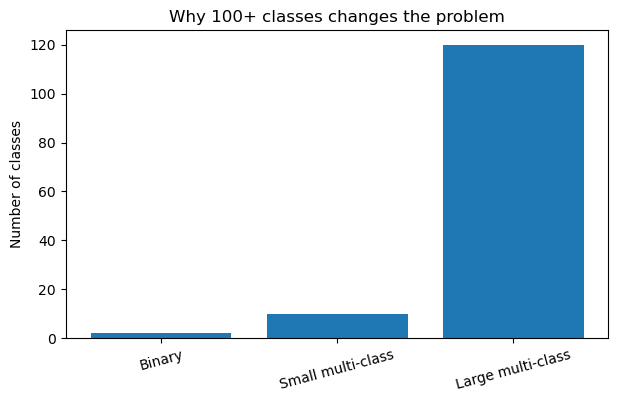

In [3]:
plt.figure(figsize=(7, 4))
plt.bar(label_space_demo["problem_type"], label_space_demo["num_classes"])
plt.title("Why 100+ classes changes the problem")
plt.ylabel("Number of classes")
plt.xticks(rotation=15)
plt.show()

# Stage 2 — Build a Synthetic Insurance Document Dataset

실제 보험 문서 텍스트는 개인정보와 규제 이슈 때문에 공개 데이터로 구하기 어렵습니다.  
따라서 여기서는 **면접 학습용 synthetic dataset**을 만듭니다.

중요한 점은 synthetic이라도 다음 현실적인 문제를 일부러 넣는 것입니다.

- 100+ document classes
- Class imbalance / long-tail
- Similar document types
- OCR noise
- Rare classes
- Unknown classes not seen during training
- Metadata
- PII redaction example

---

## Synthetic taxonomy

우리는 다음 계층을 만듭니다.

1. **Line of business**
   - Auto, Property, Medical, Legal, Payment, Correspondence

2. **Document group**
   - Report, Estimate, Bill, Record, Legal Notice, Invoice, Form, Letter, etc.

3. **Detailed document type**
   - Auto Police Report
   - Auto Repair Estimate
   - Medical Bill Emergency Room
   - Attorney Representation Letter
   - Settlement Demand Letter
   - Rental Car Invoice
   - Property Roof Estimate
   - etc.

실제 인터뷰에서는 이 taxonomy를 누가 관리하는지, 얼마나 자주 바뀌는지가 중요합니다.

In [4]:
# ============================================================
# 1. Synthetic taxonomy generation
# ============================================================

line_of_businesses = {
    "Auto": {
        "groups": ["Police Report", "Repair Estimate", "Rental", "Vehicle Damage", "Driver Statement"],
        "details": {
            "Police Report": ["Crash Report", "Supplemental Police Report", "Officer Narrative", "Citation Report"],
            "Repair Estimate": ["Body Shop Estimate", "Supplemental Estimate", "Parts Estimate", "Labor Estimate", "Total Loss Estimate"],
            "Rental": ["Rental Car Invoice", "Rental Extension Request", "Loss of Use Statement"],
            "Vehicle Damage": ["Photo Notice", "Damage Appraisal", "Towing Receipt", "Storage Fee Invoice"],
            "Driver Statement": ["Insured Statement", "Claimant Statement", "Witness Statement", "Recorded Interview Summary"]
        }
    },
    "Property": {
        "groups": ["Property Estimate", "Proof of Loss", "Inspection", "Contractor", "Weather"],
        "details": {
            "Property Estimate": ["Roof Estimate", "Water Mitigation Estimate", "Fire Damage Estimate", "Contents Estimate", "Mold Remediation Estimate"],
            "Proof of Loss": ["Sworn Proof of Loss", "Inventory Form", "Ownership Proof", "Mortgagee Statement"],
            "Inspection": ["Field Inspection Report", "Engineering Report", "Cause of Loss Report", "Photo Sheet"],
            "Contractor": ["Contractor Invoice", "Contractor Bid", "Repair Completion Certificate"],
            "Weather": ["Hail Report", "Wind Report", "Flood Zone Document", "Lightning Report"]
        }
    },
    "Medical": {
        "groups": ["Medical Bill", "Medical Record", "Treatment", "Pharmacy", "Provider"],
        "details": {
            "Medical Bill": ["Emergency Room Bill", "Ambulance Bill", "Radiology Bill", "Physical Therapy Bill", "Chiropractic Bill", "Specialist Bill"],
            "Medical Record": ["ER Medical Record", "Primary Care Note", "Radiology Report", "Surgery Note", "Discharge Summary", "Treatment Plan"],
            "Treatment": ["Physical Therapy Note", "Chiropractic Note", "Pain Management Note", "Work Status Note"],
            "Pharmacy": ["Prescription Receipt", "Medication List", "Pharmacy Invoice"],
            "Provider": ["Provider Lien", "Provider Correspondence", "Medical Authorization Form"]
        }
    },
    "Legal": {
        "groups": ["Attorney", "Demand", "Litigation", "Subrogation", "Compliance"],
        "details": {
            "Attorney": ["Attorney Representation Letter", "Attorney Correspondence", "Attorney Fee Agreement"],
            "Demand": ["Settlement Demand Letter", "Policy Limit Demand", "Demand Package Cover Letter", "Demand Supplement"],
            "Litigation": ["Summons and Complaint", "Discovery Request", "Deposition Notice", "Court Order", "Mediation Statement"],
            "Subrogation": ["Subrogation Notice", "Arbitration Filing", "Recovery Demand", "Intercompany Arbitration"],
            "Compliance": ["Medicare Compliance Letter", "HIPAA Authorization", "Release of Claims", "Minor Settlement Petition"]
        }
    },
    "Payment": {
        "groups": ["Invoice", "Receipt", "Check", "Reimbursement", "Tax"],
        "details": {
            "Invoice": ["Vendor Invoice", "Service Invoice", "Storage Invoice", "Towing Invoice", "Rental Invoice"],
            "Receipt": ["Repair Receipt", "Medical Receipt", "Lodging Receipt", "Travel Receipt", "Out of Pocket Receipt"],
            "Check": ["Check Copy", "Payment Stop Request", "Electronic Payment Form", "ACH Authorization"],
            "Reimbursement": ["Mileage Reimbursement Form", "Expense Reimbursement Form", "Wage Loss Statement", "Lost Income Verification"],
            "Tax": ["W9 Form", "1099 Document", "Tax Identification Form"]
        }
    },
    "Correspondence": {
        "groups": ["General Letter", "Email", "Notice", "Form", "Customer Upload"],
        "details": {
            "General Letter": ["Customer Letter", "Claim Acknowledgment Letter", "Coverage Letter", "Status Letter"],
            "Email": ["Customer Email", "Agent Email", "Vendor Email", "Provider Email"],
            "Notice": ["Notice of Claim", "Coverage Reservation Letter", "Denial Letter", "Closing Notice"],
            "Form": ["Claim Intake Form", "Contact Information Form", "Consent Form", "Address Change Form"],
            "Customer Upload": ["Miscellaneous Upload", "Unclear Document", "Duplicate Submission", "Blank Page"]
        }
    }
}

taxonomy_rows = []
for lob, lob_info in line_of_businesses.items():
    for group, details in lob_info["details"].items():
        for detail in details:
            taxonomy_rows.append({
                "line_of_business": lob,
                "document_group": group,
                "document_type": f"{lob} - {detail}"
            })

taxonomy = pd.DataFrame(taxonomy_rows)
taxonomy["class_id"] = range(len(taxonomy))

print("Number of document types:", len(taxonomy))
taxonomy.head(12)

Number of document types: 123


,line_of_business,document_group,document_type,class_id
0,Auto,Police Report,Auto - Crash Report,0
1,Auto,Police Report,Auto - Supplemental Police Report,1
2,Auto,Police Report,Auto - Officer Narrative,2
3,Auto,Police Report,Auto - Citation Report,3
4,Auto,Repair Estimate,Auto - Body Shop Estimate,4
5,Auto,Repair Estimate,Auto - Supplemental Estimate,5
6,Auto,Repair Estimate,Auto - Parts Estimate,6
7,Auto,Repair Estimate,Auto - Labor Estimate,7
8,Auto,Repair Estimate,Auto - Total Loss Estimate,8
9,Auto,Rental,Auto - Rental Car Invoice,9


In [5]:
taxonomy.groupby("line_of_business")["document_type"].nunique().sort_values(ascending=False)

line_of_business
Medical           22
Payment           21
Correspondence    20
Auto              20
Legal             20
Property          20
Name: document_type, dtype: int64

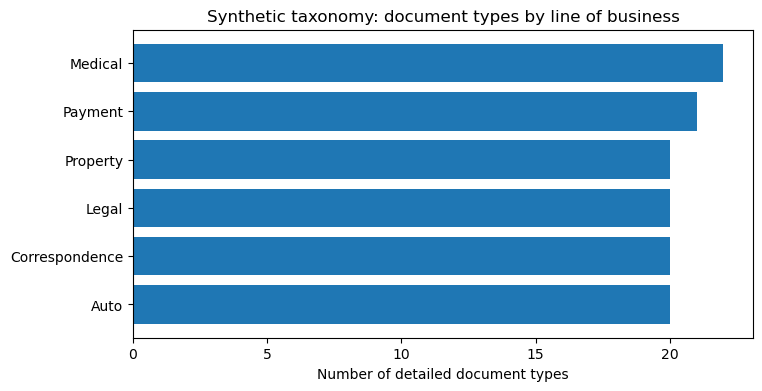

In [6]:
lob_counts = taxonomy.groupby("line_of_business")["document_type"].nunique().sort_values(ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(lob_counts.index, lob_counts.values)
plt.title("Synthetic taxonomy: document types by line of business")
plt.xlabel("Number of detailed document types")
plt.show()

# Synthetic text generation

각 document type마다 문서 text를 생성합니다.

문서에는 다음이 섞입니다.

1. **Class-specific phrases**
   - 예: police report, repair estimate, attorney representation, medical bill

2. **Shared insurance phrases**
   - 예: claim number, policyholder, date of loss, claim file

3. **Noise**
   - OCR typo
   - repeated template language
   - missing words
   - similar wording across classes

4. **PII**
   - 이름, 전화번호, claim number처럼 민감할 수 있는 텍스트
   - 나중에 redaction 예시로 사용

---

## 왜 일부러 noise를 넣나?

너무 쉬운 synthetic data는 모든 모델이 거의 완벽하게 맞춥니다.  
그러면 학습 효과가 떨어집니다.

따라서 이 노트북에서는:
- 비슷한 class끼리 헷갈리게 만들고
- rare class를 만들고
- OCR noise를 넣고
- unknown class를 따로 빼서

실제 large-scale document classification의 어려움을 체험하게 합니다.

In [7]:
# ============================================================
# 2. Synthetic document text generation
# ============================================================

common_phrases = [
    "claim number {claim_id}",
    "policyholder {name}",
    "date of loss {date}",
    "received through {channel}",
    "document uploaded to claim file",
    "please review and route to the appropriate workflow",
    "insurance claim documentation",
    "related to claim handling and coverage review",
]

lob_phrases = {
    "Auto": [
        "auto accident", "vehicle collision", "driver involved", "vehicle damage", "insured vehicle",
        "claimant vehicle", "roadway", "traffic", "repair facility", "liability review"
    ],
    "Property": [
        "property damage", "dwelling", "roof", "water damage", "fire damage",
        "contractor", "inspection", "homeowner", "repair scope", "cause of loss"
    ],
    "Medical": [
        "medical provider", "patient", "treatment", "diagnosis", "procedure code",
        "bill charges", "medical record", "clinical note", "therapy", "injury treatment"
    ],
    "Legal": [
        "attorney", "legal representation", "settlement", "litigation", "demand",
        "court", "release", "compliance", "subrogation", "negotiation"
    ],
    "Payment": [
        "invoice", "payment request", "amount due", "receipt", "reimbursement",
        "vendor", "check", "ACH", "expense", "tax form"
    ],
    "Correspondence": [
        "letter", "email", "notice", "customer message", "general correspondence",
        "status update", "coverage question", "claim inquiry", "form submission"
    ],
}

group_phrases = {
    "Police Report": ["police department", "officer narrative", "crash report", "citation", "incident number"],
    "Repair Estimate": ["estimate total", "parts labor", "body shop", "supplemental estimate", "repair line items"],
    "Rental": ["rental car", "daily rate", "rental period", "extension request", "loss of use"],
    "Vehicle Damage": ["damage photos", "appraisal", "towing", "storage fees", "vehicle inspection"],
    "Driver Statement": ["statement", "recorded interview", "witness", "driver account", "accident description"],
    "Property Estimate": ["repair estimate", "scope of work", "materials", "labor cost", "contractor estimate"],
    "Proof of Loss": ["sworn statement", "proof of loss", "inventory", "ownership", "signed form"],
    "Inspection": ["inspection report", "field adjuster", "engineering review", "cause determination", "photos attached"],
    "Contractor": ["contractor invoice", "bid", "completion certificate", "repair work", "vendor"],
    "Weather": ["hail", "wind", "storm", "weather report", "flood zone"],
    "Medical Bill": ["itemized bill", "provider charges", "CPT code", "billing date", "amount charged"],
    "Medical Record": ["clinical record", "diagnosis", "treatment note", "exam findings", "discharge"],
    "Treatment": ["therapy note", "treatment plan", "pain level", "range of motion", "work status"],
    "Pharmacy": ["prescription", "medication", "pharmacy", "dosage", "receipt"],
    "Provider": ["provider letter", "medical authorization", "lien", "provider correspondence", "HIPAA"],
    "Attorney": ["representation", "attorney letter", "law office", "client", "all communications"],
    "Demand": ["settlement demand", "policy limits", "demand package", "injury damages", "deadline"],
    "Litigation": ["complaint", "summons", "discovery", "deposition", "court filing"],
    "Subrogation": ["subrogation", "recovery", "arbitration", "third party", "liability carrier"],
    "Compliance": ["Medicare", "HIPAA", "release", "minor settlement", "compliance review"],
    "Invoice": ["invoice number", "amount due", "service date", "vendor", "balance"],
    "Receipt": ["receipt", "paid amount", "transaction", "customer paid", "proof of payment"],
    "Check": ["check number", "payment issued", "stop payment", "electronic payment", "ACH"],
    "Reimbursement": ["reimbursement", "mileage", "lost wages", "expense", "income verification"],
    "Tax": ["tax identification", "W9", "1099", "TIN", "payer"],
    "General Letter": ["letter", "coverage", "claim status", "acknowledgment", "policyholder"],
    "Email": ["email", "from", "to", "subject", "message"],
    "Notice": ["notice", "reservation of rights", "denial", "closing", "coverage"],
    "Form": ["form", "contact information", "consent", "address change", "signature"],
    "Customer Upload": ["upload", "unclear", "duplicate", "blank page", "miscellaneous"],
}

specific_phrases = {
    "Crash Report": ["traffic crash report", "diagram of collision", "officer badge", "vehicle one vehicle two"],
    "Supplemental Police Report": ["supplemental narrative", "additional officer findings", "amended crash report"],
    "Officer Narrative": ["officer narrative", "unit one stated", "unit two stated", "scene investigation"],
    "Citation Report": ["citation issued", "traffic violation", "citation number", "failure to yield"],

    "Body Shop Estimate": ["body shop estimate", "paint labor", "replace bumper", "repair quarter panel"],
    "Supplemental Estimate": ["supplement request", "additional hidden damage", "supplemental repair estimate"],
    "Parts Estimate": ["OEM parts", "aftermarket parts", "parts list", "part number"],
    "Labor Estimate": ["labor hours", "mechanical labor", "paint labor", "frame labor"],
    "Total Loss Estimate": ["actual cash value", "total loss evaluation", "salvage value", "vehicle valuation"],

    "Emergency Room Bill": ["emergency department", "ER charges", "triage", "facility fee"],
    "Ambulance Bill": ["ambulance transport", "EMS", "mileage charge", "paramedic"],
    "Radiology Bill": ["x-ray", "MRI", "CT scan", "radiology charges"],
    "Physical Therapy Bill": ["physical therapy", "therapeutic exercise", "PT visit", "rehabilitation"],
    "Chiropractic Bill": ["chiropractic adjustment", "spinal manipulation", "chiropractor"],
    "Specialist Bill": ["orthopedic specialist", "specialist consultation", "follow up visit"],

    "Attorney Representation Letter": ["letter of representation", "our firm represents", "direct all communication to counsel"],
    "Settlement Demand Letter": ["settlement demand", "demand amount", "pain and suffering", "medical specials"],
    "Policy Limit Demand": ["policy limits demand", "tender limits", "time limited demand"],
    "Summons and Complaint": ["summons", "complaint", "defendant", "civil action"],
    "Discovery Request": ["interrogatories", "request for production", "discovery responses"],

    "W9 Form": ["request for taxpayer identification", "W-9", "certification", "TIN"],
    "1099 Document": ["1099", "tax year", "nonemployee compensation", "payer"],
    "Claim Intake Form": ["initial claim intake", "loss details", "reported by", "contact information"],
    "Unclear Document": ["unreadable upload", "unclear document", "image quality poor", "manual review required"],
    "Blank Page": ["blank page", "no visible text", "empty scan", "no content detected"]
}

names = ["John Smith", "Mary Johnson", "David Lee", "Susan Kim", "Robert Brown", "Patricia Davis"]
channels = ["web portal", "mobile app", "email", "fax", "agent upload", "mailroom scan"]
states = ["OH", "GA", "IL", "TX", "AZ", "FL", "NY", "CA", "NC", "PA"]

def random_date():
    month = np.random.randint(1, 13)
    day = np.random.randint(1, 28)
    return f"2025-{month:02d}-{day:02d}"

def maybe_ocr_noise(text, severity=0.0):
    if severity <= 0:
        return text
    chars = list(text)
    replacements = {"o": "0", "O": "0", "l": "1", "I": "1", "e": "c", "a": "@", "s": "5"}
    for i, ch in enumerate(chars):
        if np.random.rand() < severity * 0.04 and ch in replacements:
            chars[i] = replacements[ch]
        elif np.random.rand() < severity * 0.015 and ch.isalpha():
            chars[i] = ""  # dropped OCR character
    return "".join(chars)

def generate_doc_text(row, claim_id, add_pii=True, ocr_noise=0.0, template_variant=None):
    lob = row["line_of_business"]
    group = row["document_group"]
    doc_type_full = row["document_type"]
    detail = doc_type_full.split(" - ", 1)[1]
    name = random.choice(names)
    channel = random.choice(channels)
    date = random_date()

    parts = []
    parts.append(random.choice(common_phrases).format(claim_id=claim_id, name=name, date=date, channel=channel))
    parts.append(random.choice(common_phrases).format(claim_id=claim_id, name=name, date=date, channel=channel))

    parts += random.sample(lob_phrases[lob], k=min(3, len(lob_phrases[lob])))
    parts += random.sample(group_phrases[group], k=min(3, len(group_phrases[group])))

    if detail in specific_phrases:
        parts += random.sample(specific_phrases[detail], k=min(3, len(specific_phrases[detail])))
    else:
        # use detail words as signal, but not too perfectly
        parts += re.sub(r"[^A-Za-z ]", " ", detail).lower().split()[:3]

    # shared ambiguous phrases to make classification harder
    if np.random.rand() < 0.25:
        parts += random.sample(["review document", "supporting documentation", "claim file", "attached pages", "workflow routing"], 2)

    if add_pii and np.random.rand() < 0.25:
        parts.append(f"phone 614-555-{np.random.randint(1000,9999)}")
        parts.append(f"email customer{np.random.randint(1,999)}@example.com")

    random.shuffle(parts)
    text = ". ".join(parts) + "."

    # make some documents longer
    if np.random.rand() < 0.15:
        text = text + " " + " ".join(np.random.choice(parts, size=np.random.randint(5, 15), replace=True))

    text = maybe_ocr_noise(text, severity=ocr_noise)
    return text

print("Text generation functions ready.")

Text generation functions ready.


# Generate long-tail class distribution

실제 document classification에서는 모든 class가 같은 빈도로 나오지 않습니다.

대부분의 production dataset은 **long-tail**입니다.

- 몇몇 document type은 매우 많음
- 많은 document type은 매우 적음
- rare class의 recall이 낮아질 수 있음

이게 이메일에서 말한 **class imbalance**입니다.

In [8]:
# ============================================================
# 3. Generate long-tail synthetic data
# ============================================================

def make_long_tail_counts(n_classes, min_count=18, max_count=420, alpha=1.15):
    # Zipf-like long tail
    ranks = np.arange(1, n_classes + 1)
    weights = 1 / (ranks ** alpha)
    weights = weights / weights.max()
    counts = min_count + (max_count - min_count) * weights
    counts = counts.astype(int)
    # shuffle counts so large classes are not all in the first LOB
    np.random.shuffle(counts)
    return counts

taxonomy = taxonomy.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
taxonomy["sample_count"] = make_long_tail_counts(len(taxonomy), min_count=16, max_count=360)

# Choose some classes as unknown classes that will not appear in training.
# These simulate new/unexpected document types in production.
UNKNOWN_CLASS_COUNT = 8
unknown_classes = taxonomy.sample(UNKNOWN_CLASS_COUNT, random_state=RANDOM_STATE + 10)["document_type"].tolist()

rows = []
claim_counter = 100000
for _, trow in taxonomy.iterrows():
    doc_type = trow["document_type"]
    n = int(trow["sample_count"])
    for _ in range(n):
        claim_counter += 1
        ocr_quality = np.clip(np.random.beta(8, 2), 0, 1)
        # Lower quality means higher noise severity
        noise_severity = max(0, 1 - ocr_quality)
        text = generate_doc_text(trow, claim_id=f"CLM{claim_counter}", add_pii=True, ocr_noise=noise_severity)
        rows.append({
            "document_id": f"DOC{claim_counter}",
            "claim_id": f"CLM{claim_counter}",
            "text": text,
            "document_type": doc_type,
            "line_of_business": trow["line_of_business"],
            "document_group": trow["document_group"],
            "source_channel": random.choice(channels),
            "state": random.choice(states),
            "page_count": int(np.clip(np.random.poisson(3) + 1, 1, 25)),
            "ocr_quality": float(ocr_quality),
            "is_unknown_class": doc_type in unknown_classes,
        })

df = pd.DataFrame(rows)

print("Total documents:", len(df))
print("Total document types:", df["document_type"].nunique())
print("Known classes:", df.loc[~df["is_unknown_class"], "document_type"].nunique())
print("Unknown holdout classes:", df.loc[df["is_unknown_class"], "document_type"].nunique())

df.head()

Total documents: 3287
Total document types: 123
Known classes: 115
Unknown holdout classes: 8


,document_id,claim_id,text,document_type,line_of_business,document_group,source_channel,state,page_count,ocr_quality,is_unknown_class
0,DOC100001,CLM100001,driver involved. liability review. vehiclc damage. statement. statement. documcnt uploaded to claim file. witness. witness. claim number CLM100001. accident...,Auto - Witness Statement,Auto,Driver Statement,mailroom scan,NC,5,0.543693,False
1,DOC100002,CLM100002,email customer634@example.com. witness. statement. roadway. phone 614-555-7938. auto @ccident. related to claim handling and coveragc review. accident descr...,Auto - Witness Statement,Auto,Driver Statement,agent upload,GA,3,0.895060,False
2,DOC100003,CLM100003,document uploaded to claim file. driver account. witness. statement. liability review. statement. phone 614-555-2949. vehicle collsion. recorded interview. ...,Auto - Witness Statement,Auto,Driver Statement,mobile app,AZ,7,0.733210,False
3,DOC100004,CLM100004,date of loss 2025-10-06. driver involved. recorded interview. supporting documentation. witness. repair facility. accident description. statement. vehicle d...,Auto - Witness Statement,Auto,Driver Statement,agent upload,FL,4,0.988667,False
4,DOC100005,CLM100005,traffic. related to claim handling and coverage review. insurance claim documentation. accident description. driver involved. witness. recorded interview. i...,Auto - Witness Statement,Auto,Driver Statement,mobile app,NC,6,0.913065,False


In [9]:
# Class distribution: top and bottom
class_counts = df.groupby("document_type").size().sort_values(ascending=False)

display(class_counts.head(10).to_frame("count"))
display(class_counts.tail(10).to_frame("count"))

,count
document_type,
Auto - Crash Report,360
Auto - Supplemental Police Report,171
Auto - Officer Narrative,113
Auto - Citation Report,85
Auto - Body Shop Estimate,70
Auto - Supplemental Estimate,59
Auto - Parts Estimate,52
Auto - Labor Estimate,47
Auto - Total Loss Estimate,43


,count
document_type,
Payment - Check Copy,17
Payment - ACH Authorization,17
Payment - 1099 Document,17
Payment - W9 Form,17
Payment - Wage Loss Statement,17
Payment - Travel Receipt,17
Payment - Repair Receipt,17
Payment - Payment Stop Request,17
Payment - Out of Pocket Receipt,17


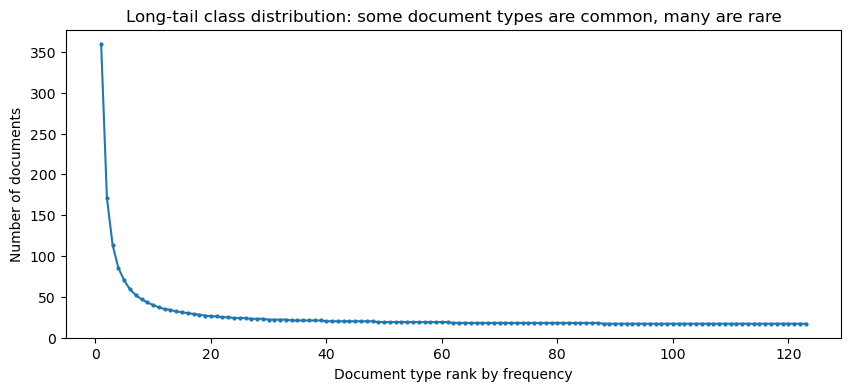

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, len(class_counts)+1), class_counts.values, marker="o", markersize=2)
plt.title("Long-tail class distribution: some document types are common, many are rare")
plt.xlabel("Document type rank by frequency")
plt.ylabel("Number of documents")
plt.show()

## Interview interpretation

위 plot이 바로 100+ class 문제의 핵심입니다.

Binary classification에서는 보통 `positive class를 얼마나 잘 잡는가`가 중심입니다.  
하지만 100+ document classes에서는:

- common classes는 잘 맞추는데 rare classes는 못 맞출 수 있음
- overall accuracy는 높아 보이지만 macro F1은 낮을 수 있음
  - Macro F1: 모든 클래스를 똑같이 중요하게 평가 
- rare legal/compliance documents를 놓치면 business risk가 클 수 있음

### 영어로 말하기

> I would first inspect the class distribution because document classification usually has a long-tail problem.  
> Some document types may have thousands of examples, while rare legal or compliance documents may have very few.  
> That means I should evaluate macro F1 and per-class recall, not just overall accuracy.

# PII redaction example

보험 문서에는 이름, 전화번호, 이메일, claim number 같은 정보가 있을 수 있습니다.

모델링 전에 반드시 생각해야 할 질문:

- Do we need to mask PII before training?
- Are claim numbers or policy numbers useful, or are they leakage / memorization risk?
- Can the model memorize customer-specific information?
- What is allowed in a regulated environment?

여기서는 간단한 regex redaction 예시를 보여줍니다.

In [11]:
# ============================================================
# 4. Simple PII redaction demonstration
# ============================================================

sample_text = df["text"].iloc[0]
print("Original text:\n")
print(sample_text)

def redact_pii(text):
    text = re.sub(r"\b\d{3}-\d{3}-\d{4}\b", "[PHONE]", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", "[EMAIL]", text)
    text = re.sub(r"\bCLM\d+\b", "[CLAIM_ID]", text)
    # very simple name masking example using known synthetic names
    for name in names:
        text = text.replace(name, "[NAME]")
    return text

print("\nRedacted text:\n")
print(redact_pii(sample_text))

df["text_redacted"] = df["text"].apply(redact_pii)

Original text:

driver involved. liability review. vehiclc damage. statement. statement. documcnt uploaded to claim file. witness. witness. claim number CLM100001. accident description.

Redacted text:

driver involved. liability review. vehiclc damage. statement. statement. documcnt uploaded to claim file. witness. witness. claim number [CLAIM_ID]. accident description.


## Interview wording

> Before training, I would review PII handling.  
> Some identifiers like claim number or policy number may not generalize and may create privacy or memorization risk.  
> I would either remove or mask PII and keep only information that is appropriate and useful for document classification.

# Train / Validation / Test split with unknown classes

이번 문제에서는 unknown class를 따로 다룹니다.

- **Known classes**: training에 등장하는 100+ document types
- **Unknown classes**: training에는 없고 production/test에서 갑자기 등장하는 document types

Closed-set classifier는 unknown document가 들어와도 반드시 known class 중 하나로 억지 분류합니다.  
그래서 unknown handling이 필요합니다.

In [12]:
# ============================================================
# 5. Train/validation/test split
# ============================================================

known_df = df[~df["is_unknown_class"]].copy()
unknown_df = df[df["is_unknown_class"]].copy()

# First split known classes into train and temp
train_df, temp_df = train_test_split(
    known_df,
    test_size=0.35,
    stratify=known_df["document_type"],
    random_state=RANDOM_STATE
)

val_df, test_known_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["document_type"],
    random_state=RANDOM_STATE
)

# unknown test set
test_unknown_df = unknown_df.copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Known test:", test_known_df.shape)
print("Unknown test:", test_unknown_df.shape)

print("Known train classes:", train_df["document_type"].nunique())
print("Unknown test classes:", test_unknown_df["document_type"].nunique())

Train: (1730, 12)
Validation: (466, 12)
Known test: (466, 12)
Unknown test: (625, 12)
Known train classes: 115
Unknown test classes: 8


# Stage 2 — Data Exploration

면접에서 data exploration은 단순 EDA가 아니라 **model strategy를 정하기 위한 질문**입니다.

봐야 할 것:

1. Class distribution
2. Rare class coverage
3. Text length
4. OCR quality
5. Similar classes
6. Metadata availability
7. Unknown/new class risk

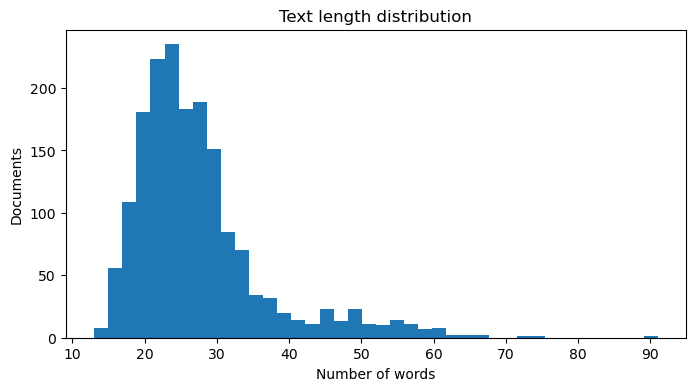

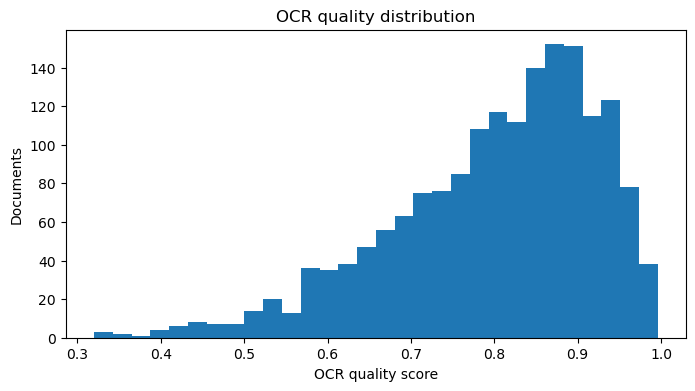

In [18]:
# Text length and OCR quality
train_df["text_length"] = train_df["text_redacted"].str.split().apply(len)

plt.figure(figsize=(8, 4))
plt.hist(train_df["text_length"], bins=40)
plt.title("Text length distribution")
plt.xlabel("Number of words")
plt.ylabel("Documents")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(train_df["ocr_quality"], bins=30)
plt.title("OCR quality distribution")
plt.xlabel("OCR quality score")
plt.ylabel("Documents")
plt.show()

In [19]:
# Rare class inspection
train_counts = train_df.groupby("document_type").size().sort_values()
rare_classes = train_counts[train_counts <= train_counts.quantile(0.15)]

print("Number of rare classes in train:", len(rare_classes))
display(rare_classes.head(15).to_frame("train_count"))

Number of rare classes in train: 33


,train_count
document_type,
Correspondence - Address Change Form,11
Correspondence - Provider Email,11
Correspondence - Notice of Claim,11
Correspondence - Miscellaneous Upload,11
Correspondence - Duplicate Submission,11
Correspondence - Denial Letter,11
Correspondence - Customer Letter,11
Correspondence - Customer Email,11
Correspondence - Coverage Reservation Letter,11


## Interview wording: data exploration

> I would explore the class distribution, text length, OCR quality, and label quality before choosing a model.  
> With 100+ document types, I would specifically look for long-tail classes and similar document types that may be confused with each other.  
> I would also check whether metadata such as source channel, page count, or line of business is available at prediction time.

# Stage 2 — Model Selection Strategy

## Closed-set supervised classifier

For known, fixed classes:
- TF-IDF + Logistic Regression
- TF-IDF + Linear SVM
- Fine-tuned transformer classifier

Good when:
- class taxonomy is stable
- enough labeled examples per class
- top-1 prediction is required
- latency and cost matter

## Embedding / similarity approach

Good when:
- new document types are frequently added
- rare classes have very few examples
- we want nearest-class suggestions
- human review can use top-k candidates

## Hierarchical classification

Good when:
- label space is very large
- taxonomy has natural hierarchy
- first classify high-level category, then detailed type

Risk:
- If top-level prediction is wrong, downstream predictions can cascade incorrectly.

---

## Interview wording

> I would start with a simple, strong baseline such as TF-IDF plus a linear classifier.  
> For a regulated production setting, this gives me a fast and interpretable benchmark.  
> Then I would compare it with transformer-based or embedding-based approaches, especially if we need better semantic understanding, unknown detection, or support for new document classes.

# Mini warm-up: 10 classes for intuition

이 섹션은 본론이 아닙니다.  
단지 TF-IDF classifier가 어떻게 동작하는지 직관적으로 보기 위한 작은 예제입니다.

본론은 이후의 **100+ class classification**입니다.

In [20]:
# ============================================================
# 6. Warm-up: 10-class model
# ============================================================

top10_classes = train_df["document_type"].value_counts().head(10).index.tolist() # 빈도별 상위 10개
small_train = train_df[train_df["document_type"].isin(top10_classes)].copy()
small_val = val_df[val_df["document_type"].isin(top10_classes)].copy()

small_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)),
    ("clf", LogisticRegression(max_iter=1000, class_weight=None, random_state=RANDOM_STATE))
])

small_model.fit(small_train["text_redacted"], small_train["document_type"])
small_pred = small_model.predict(small_val["text_redacted"])

print("Warm-up 10-class accuracy:", round(accuracy_score(small_val["document_type"], small_pred), 3))
print("Warm-up 10-class macro F1:", round(f1_score(small_val["document_type"], small_pred, average="macro"), 3))

Warm-up 10-class accuracy: 1.0
Warm-up 10-class macro F1: 1.0


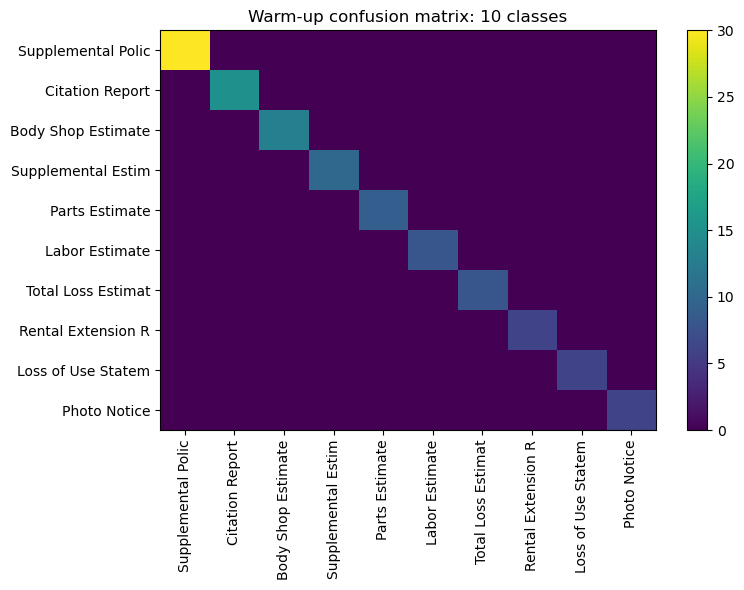

In [21]:
# Show a small confusion matrix for intuition
cm = confusion_matrix(small_val["document_type"], small_pred, labels=top10_classes)

plt.figure(figsize=(8, 6))
plt.imshow(cm, aspect="auto")
plt.title("Warm-up confusion matrix: 10 classes")
plt.xticks(range(len(top10_classes)), [c.split(" - ")[-1][:18] for c in top10_classes], rotation=90)
plt.yticks(range(len(top10_classes)), [c.split(" - ")[-1][:18] for c in top10_classes])
plt.colorbar()
plt.tight_layout()
plt.show()

# Stage 3 — Main model: 100+ class TF-IDF baseline

이제 실제 케이스에 맞게 100+ document types를 대상으로 학습합니다.

## 왜 baseline부터 시작하나?

면접에서 처음부터 “BERT 쓰겠습니다”라고 하면 약할 수 있습니다.  
강한 답변은 보통 다음과 같습니다.

> I would first build a simple but strong baseline.  
> TF-IDF plus a linear classifier is fast, interpretable, and often surprisingly strong for document classification.  
> Then I would compare more advanced models against that baseline.

여기서는 두 가지를 비교합니다.

1. TF-IDF + Logistic Regression
2. TF-IDF + Logistic Regression with class_weight='balanced'

In [22]:
# ============================================================
# 7. Main models: 100+ class TF-IDF
# ============================================================

baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=12000, ngram_range=(1, 2), min_df=2, max_df=0.95)),
    ("clf", LogisticRegression(max_iter=1200, n_jobs=-1, random_state=RANDOM_STATE))
])

balanced_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=12000, ngram_range=(1, 2), min_df=2, max_df=0.95)),
    ("clf", LogisticRegression(max_iter=1200, n_jobs=-1, class_weight="balanced", random_state=RANDOM_STATE))
])

print("Training baseline model...")
baseline_model.fit(train_df["text_redacted"], train_df["document_type"])

print("Training class-weighted model...")
balanced_model.fit(train_df["text_redacted"], train_df["document_type"])

print("Models trained.")

Training baseline model...
Training class-weighted model...
Models trained.


In [23]:
def evaluate_multiclass_model(model, X, y, model_name="model"):
    pred = model.predict(X)
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "weighted_f1": f1_score(y, pred, average="weighted"),
    }
    # top-k if predict_proba exists
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        classes = model.classes_
        result["top3_accuracy"] = top_k_accuracy_score(y, proba, k=3, labels=classes)
        result["top5_accuracy"] = top_k_accuracy_score(y, proba, k=5, labels=classes)
    return result

results = []
results.append(evaluate_multiclass_model(baseline_model, val_df["text_redacted"], val_df["document_type"], "TF-IDF + Logistic"))
results.append(evaluate_multiclass_model(balanced_model, val_df["text_redacted"], val_df["document_type"], "TF-IDF + Logistic balanced"))

results_df = pd.DataFrame(results)
results_df

,model,accuracy,macro_f1,weighted_f1,top3_accuracy,top5_accuracy
0,TF-IDF + Logistic,0.826180,0.772552,0.814018,0.978541,1.0
1,TF-IDF + Logistic balanced,0.843348,0.799013,0.834056,0.980687,1.0


- Macro F1 (평등주의: "모든 클래스는 소중하다)
- Weighted F1 (현실주의: "많이 나오는 문서가 중요하다")

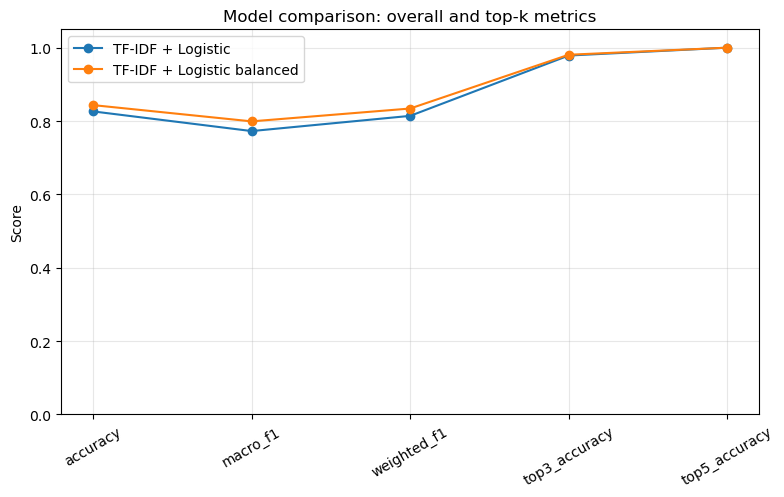

In [24]:
metrics_to_plot = ["accuracy", "macro_f1", "weighted_f1", "top3_accuracy", "top5_accuracy"]

plot_df = results_df.set_index("model")[metrics_to_plot].T

plt.figure(figsize=(9, 5))
for col in plot_df.columns:
    plt.plot(plot_df.index, plot_df[col], marker="o", label=col)
plt.title("Model comparison: overall and top-k metrics")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## How to interpret this table

- **Accuracy**: overall top-1 correctness
- **Macro F1**: each class weighted equally; sensitive to rare class performance
- **Weighted F1**: common classes get more weight
- **Top-3 accuracy**: whether the true class is in the top 3 candidates
- **Top-5 accuracy**: useful for human reviewer assistance

---

## Interview wording

> For 100+ classes, I would not rely only on accuracy.  
> I would evaluate macro F1 to understand rare class performance, weighted F1 for volume-weighted performance, and top-k accuracy because the system may support human review by showing the top candidate document types.

# Per-class performance: rare classes matter

Large label space에서는 전체 성능이 좋아 보여도 rare class는 매우 약할 수 있습니다.

여기서는 per-class recall을 확인합니다.

## Interview wording

> I would inspect per-class precision and recall, especially for rare or high-risk document types.  
> A model can have strong overall accuracy while failing rare legal, compliance, or medical document types.

In [25]:
# ============================================================
# 8. Per-class performance
# ============================================================

val_pred = balanced_model.predict(val_df["text_redacted"])

per_class = precision_recall_fscore_support(
    val_df["document_type"], val_pred, labels=balanced_model.classes_, zero_division=0
)

per_class_df = pd.DataFrame({
    "document_type": balanced_model.classes_,
    "precision": per_class[0],
    "recall": per_class[1],
    "f1": per_class[2],
    "support": per_class[3],
})
per_class_df["line_of_business"] = per_class_df["document_type"].map(
    taxonomy.set_index("document_type")["line_of_business"]
)

display(per_class_df.sort_values("recall").head(15))
display(per_class_df.sort_values("support").head(15))

,document_type,precision,recall,f1,support,line_of_business
31,Correspondence - Status Letter,0.000000,0.000000,0.000000,3,Correspondence
29,Correspondence - Notice of Claim,0.000000,0.000000,0.000000,3,Correspondence
82,Payment - Mileage Reimbursement Form,0.000000,0.000000,0.000000,3,Payment
2,Auto - Claimant Statement,1.000000,0.200000,0.333333,5,Auto
74,Medical - Treatment Plan,1.000000,0.250000,0.400000,4,Medical
22,Correspondence - Coverage Letter,0.250000,0.333333,0.285714,3,Correspondence
23,Correspondence - Coverage Reservation Letter,0.500000,0.333333,0.400000,3,Correspondence
30,Correspondence - Provider Email,0.500000,0.333333,0.400000,3,Correspondence
33,Correspondence - Vendor Email,0.500000,0.333333,0.400000,3,Correspondence
97,Property - Contractor Bid,0.500000,0.333333,0.400000,3,Property


,document_type,precision,recall,f1,support,line_of_business
15,Correspondence - Address Change Form,0.75,1.000000,0.857143,3,Correspondence
30,Correspondence - Provider Email,0.50,0.333333,0.400000,3,Correspondence
29,Correspondence - Notice of Claim,0.00,0.000000,0.000000,3,Correspondence
28,Correspondence - Miscellaneous Upload,1.00,0.666667,0.800000,3,Correspondence
27,Correspondence - Duplicate Submission,0.75,1.000000,0.857143,3,Correspondence
26,Correspondence - Denial Letter,0.25,0.333333,0.285714,3,Correspondence
25,Correspondence - Customer Letter,0.50,0.333333,0.400000,3,Correspondence
24,Correspondence - Customer Email,0.40,0.666667,0.500000,3,Correspondence
23,Correspondence - Coverage Reservation Letter,0.50,0.333333,0.400000,3,Correspondence
22,Correspondence - Coverage Letter,0.25,0.333333,0.285714,3,Correspondence


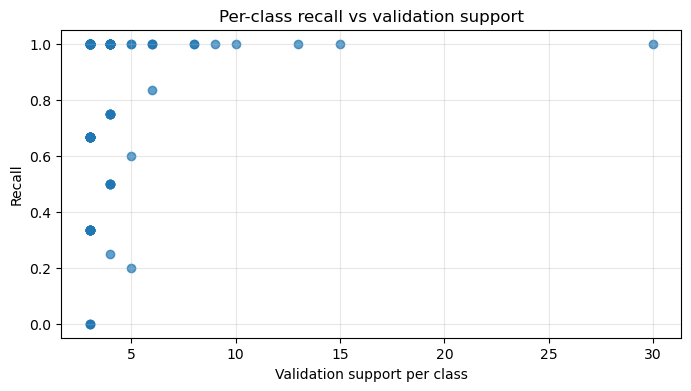

In [26]:
plt.figure(figsize=(8, 4))
plt.scatter(per_class_df["support"], per_class_df["recall"], alpha=0.7)
plt.title("Per-class recall vs validation support")
plt.xlabel("Validation support per class")
plt.ylabel("Recall")
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

- 왼쪽 하단 (데이터가 적은 곳): support가 5 이하인 영역을 보면, recall이 0.0에서 1.0까지 아주 넓게 퍼져 있습니다. 즉, 데이터가 적으면 모델이 아예 못 맞추거나(0), 운 좋게 다 맞추거나(1) 해서 성능이 매우 불안정합니다.
- 오른쪽 (데이터가 많은 곳): 데이터가 충분한 클래스들은 대부분 recall이 1.0 근처에 모여 있습니다. 모델이 데이터를 많이 본 만큼 학습을 잘했다는 뜻입니다.
- 우리 모델은 쉬운 건 다 맞추는데, 어려운 문제(희귀 문서)를 만날 때마다 실력이 들쭉날쭉하니, 이 부분에 대한 안전장치가 필요하다.

# Top-k prediction

100+ class document classification에서는 top-1만 중요한 것이 아닐 수 있습니다.

예를 들어 모델이 다음을 반환한다고 합시다.

1. Medical Record  
2. Medical Bill  
3. Treatment Plan  

정답이 2위라면, 자동 분류는 실패했지만 human reviewer에게는 여전히 유용합니다.

## Interview wording

> In a large label space, I would evaluate top-k accuracy.  
> If the model can provide the top 3 candidate document types, it may significantly reduce human review effort even when top-1 is not always correct.

In [27]:
# ============================================================
# 9. Top-k prediction examples
# ============================================================

def get_top_k_predictions(model, texts, k=3):
    proba = model.predict_proba(texts)
    classes = model.classes_
    top_idx = np.argsort(proba, axis=1)[:, ::-1][:, :k]
    rows = []
    for i in range(len(texts)):
        row = {}
        for rank in range(k):
            idx = top_idx[i, rank]
            row[f"rank_{rank+1}_class"] = classes[idx]
            row[f"rank_{rank+1}_confidence"] = proba[i, idx]
        rows.append(row)
    return pd.DataFrame(rows)

example_idx = np.random.choice(len(val_df), size=8, replace=False)
examples = val_df.iloc[example_idx][["document_id", "text_redacted", "document_type"]].reset_index(drop=True)
top3 = get_top_k_predictions(balanced_model, examples["text_redacted"], k=3)

example_topk = pd.concat([examples, top3], axis=1)
example_topk[["document_type", "rank_1_class", "rank_1_confidence", "rank_2_class", "rank_2_confidence", "rank_3_class", "rank_3_confidence"]]

,document_type,rank_1_class,rank_1_confidence,rank_2_class,rank_2_confidence,rank_3_class,rank_3_confidence
0,Auto - Parts Estimate,Auto - Parts Estimate,0.321413,Auto - Body Shop Estimate,0.029154,Auto - Supplemental Estimate,0.029144
1,Legal - Attorney Correspondence,Legal - Attorney Correspondence,0.124606,Legal - Attorney Fee Agreement,0.089232,Legal - Attorney Representation Letter,0.020577
2,Property - Sworn Proof of Loss,Property - Sworn Proof of Loss,0.196632,Property - Mortgagee Statement,0.071877,Property - Ownership Proof,0.047723
3,Correspondence - Notice of Claim,Correspondence - Denial Letter,0.053541,Correspondence - Closing Notice,0.051134,Correspondence - Notice of Claim,0.048138
4,Medical - Radiology Report,Medical - Radiology Report,0.054853,Medical - Discharge Summary,0.052244,Medical - Treatment Plan,0.045485
5,Payment - W9 Form,Payment - W9 Form,0.156222,Payment - Tax Identification Form,0.060137,Payment - 1099 Document,0.047031
6,Auto - Total Loss Estimate,Auto - Total Loss Estimate,0.277108,Auto - Body Shop Estimate,0.046506,Auto - Supplemental Estimate,0.026874
7,Correspondence - Duplicate Submission,Correspondence - Duplicate Submission,0.124460,Correspondence - Miscellaneous Upload,0.035845,Correspondence - Blank Page,0.034961


# Confidence, calibration, and human-in-the-loop

Document classification system에서 모델이 항상 자동 결정할 필요는 없습니다.

운영 설계는 다음처럼 할 수 있습니다.

| Model confidence | Action |
|---|---|
| High confidence | Auto-classify |
| Medium confidence | Show top-3 to human reviewer |
| Low confidence | Manual review / unknown queue |

이것이 **Human-in-the-loop (HITL)**입니다.

---

## Calibration이 왜 필요한가?

모델이 0.90 confident라고 했을 때 실제로 90% 정도 맞는다면 confidence를 믿을 수 있습니다.  
하지만 0.90이라고 해도 실제 정확도가 65%라면, threshold 기반 자동화가 위험합니다.

## Interview wording

> I would use confidence thresholds carefully.  
> Before auto-classifying high-confidence documents, I would check whether the model confidence is calibrated.  
> Low-confidence or high-risk documents should go to human review.

In [28]:
# ============================================================
# 10. Confidence and calibration analysis
# ============================================================

val_proba = balanced_model.predict_proba(val_df["text_redacted"])
val_classes = balanced_model.classes_
val_top1_idx = np.argmax(val_proba, axis=1)
val_confidence = val_proba[np.arange(len(val_proba)), val_top1_idx]
val_top1_pred = val_classes[val_top1_idx]
val_correct = (val_top1_pred == val_df["document_type"].values).astype(int)

calib_df = pd.DataFrame({
    "confidence": val_confidence,
    "correct": val_correct,
    "predicted": val_top1_pred,
    "actual": val_df["document_type"].values,
})

# bin by confidence
calib_df["confidence_bin"] = pd.cut(calib_df["confidence"], bins=np.linspace(0, 1, 11), include_lowest=True)
bin_summary = calib_df.groupby("confidence_bin").agg(
    n=("correct", "size"),
    avg_confidence=("confidence", "mean"),
    accuracy=("correct", "mean")
).reset_index()

bin_summary

,confidence_bin,n,avg_confidence,accuracy
0,"(-0.001, 0.1]",173,0.072897,0.693642
1,"(0.1, 0.2]",191,0.141932,0.900524
2,"(0.2, 0.3]",78,0.244088,0.987179
3,"(0.3, 0.4]",19,0.329520,1.000000
4,"(0.4, 0.5]",5,0.431331,1.000000
5,"(0.5, 0.6]",0,NaN,NaN
6,"(0.6, 0.7]",0,NaN,NaN
7,"(0.7, 0.8]",0,NaN,NaN
8,"(0.8, 0.9]",0,NaN,NaN
9,"(0.9, 1.0]",0,NaN,NaN


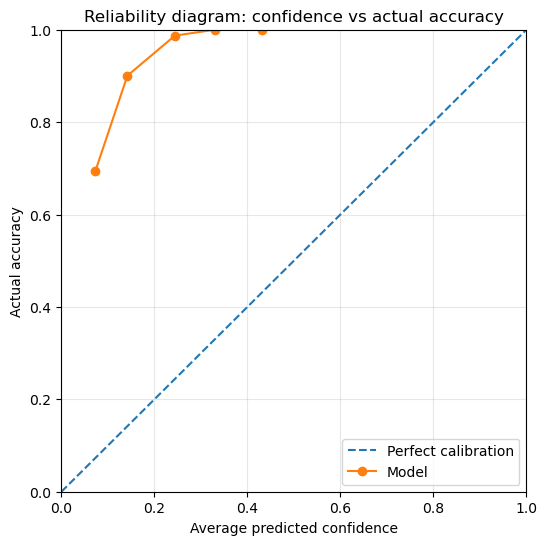

In [29]:
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(bin_summary["avg_confidence"], bin_summary["accuracy"], marker="o", label="Model")
plt.title("Reliability diagram: confidence vs actual accuracy")
plt.xlabel("Average predicted confidence")
plt.ylabel("Actual accuracy")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Auto-classify vs human review threshold

이제 confidence threshold를 바꿔보면서 다음 trade-off를 봅니다.

- threshold 낮음 → 많은 문서를 자동 분류하지만 오류도 많을 수 있음
- threshold 높음 → 자동 분류는 적지만 정확도는 높아짐
- 나머지는 human review로 보냄

## Interview wording

> I would not force every document to be auto-classified.  
> I would choose a confidence threshold based on the acceptable error rate, human review capacity, and the business risk of misclassification.

In [30]:
# ============================================================
# 11. Human-in-the-loop threshold simulation
# ============================================================

thresholds = np.arange(0.3, 0.96, 0.05)
threshold_rows = []

for th in thresholds:
    auto_mask = calib_df["confidence"] >= th
    auto_rate = auto_mask.mean()
    manual_rate = 1 - auto_rate
    auto_accuracy = calib_df.loc[auto_mask, "correct"].mean() if auto_mask.sum() > 0 else np.nan
    threshold_rows.append({
        "threshold": th,
        "auto_classification_rate": auto_rate,
        "manual_review_rate": manual_rate,
        "accuracy_on_auto_classified": auto_accuracy,
        "auto_count": int(auto_mask.sum())
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,threshold,auto_classification_rate,manual_review_rate,accuracy_on_auto_classified,auto_count
0,0.30,0.051502,0.948498,1.0,24
1,0.35,0.019313,0.980687,1.0,9
2,0.40,0.010730,0.989270,1.0,5
3,0.45,0.004292,0.995708,1.0,2
4,0.50,0.000000,1.000000,NaN,0
5,0.55,0.000000,1.000000,NaN,0
6,0.60,0.000000,1.000000,NaN,0
7,0.65,0.000000,1.000000,NaN,0
8,0.70,0.000000,1.000000,NaN,0
9,0.75,0.000000,1.000000,NaN,0


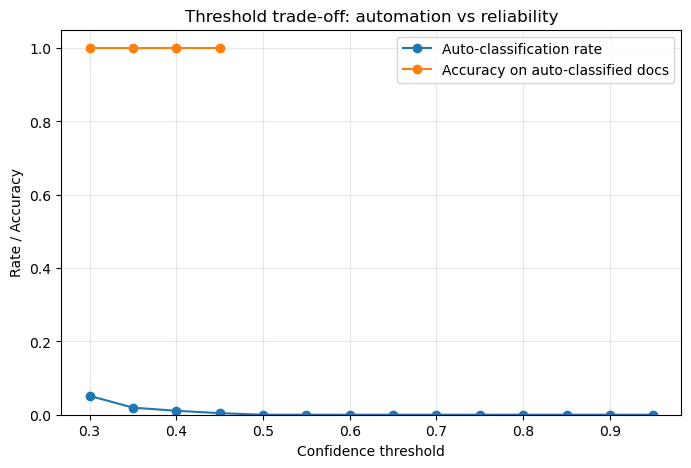

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["auto_classification_rate"], marker="o", label="Auto-classification rate")
plt.plot(threshold_df["threshold"], threshold_df["accuracy_on_auto_classified"], marker="o", label="Accuracy on auto-classified docs")
plt.title("Threshold trade-off: automation vs reliability")
plt.xlabel("Confidence threshold")
plt.ylabel("Rate / Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cost-sensitive thinking for document classification

여기서 cost-sensitive는 binary fraud/BI처럼 단순하지 않을 수 있습니다.

예를 들어:

- Medical bill을 correspondence로 잘못 분류 → payment delay
- Attorney letter를 general letter로 잘못 분류 → legal risk
- Settlement demand를 ordinary correspondence로 잘못 분류 → high business risk
- Blank page를 valid document로 잘못 분류 → workflow noise

따라서 threshold는 모든 class에 동일하지 않을 수 있습니다.

## Interview wording

> I would consider class-specific risk.  
> Misclassifying a legal demand letter may be much more costly than misclassifying a general correspondence document.  
> So for high-risk document types, I may use stricter confidence thresholds or require human review.

In [32]:
# Example: assign simple risk tiers by line of business/group
risk_map = {
    "Legal": "High",
    "Medical": "Medium-High",
    "Payment": "Medium",
    "Property": "Medium",
    "Auto": "Medium",
    "Correspondence": "Low"
}

calib_df["actual_lob"] = calib_df["actual"].map(taxonomy.set_index("document_type")["line_of_business"])
calib_df["risk_tier"] = calib_df["actual_lob"].map(risk_map)

risk_summary = calib_df.groupby("risk_tier").agg(
    n=("correct", "size"),
    accuracy=("correct", "mean"),
    avg_confidence=("confidence", "mean")
).sort_values("accuracy")

risk_summary

,n,accuracy,avg_confidence
risk_tier,,,
Low,57,0.614035,0.117540
Medium,271,0.867159,0.149696
Medium-High,78,0.871795,0.142969
High,60,0.916667,0.145959


# Unknown / unexpected document types

> Unknown / unexpected document types  
> how you detect or handle classes not seen in training

Closed-set classifier는 모르는 문서도 반드시 known class 중 하나로 분류합니다.  
따라서 production에서는 다음을 설계해야 합니다.

- confidence threshold
- top1-top2 margin threshold
- unknown/manual review queue
- human labeling feedback
- retraining or taxonomy update

## Interview wording

> A standard classifier is usually closed-set.  
> If an unseen document type appears in production, the model will still force it into one of the known classes.  
> So I would design an unknown handling process using confidence, margin, or embedding similarity thresholds, and route uncertain documents to human review.

In [33]:
# ============================================================
# 12. Unknown class detection demonstration
# ============================================================

known_test_proba = balanced_model.predict_proba(test_known_df["text_redacted"])
unknown_test_proba = balanced_model.predict_proba(test_unknown_df["text_redacted"])

def confidence_and_margin(proba):
    sorted_p = np.sort(proba, axis=1)[:, ::-1]
    confidence = sorted_p[:, 0]
    margin = sorted_p[:, 0] - sorted_p[:, 1]
    return confidence, margin

known_conf, known_margin = confidence_and_margin(known_test_proba)
unknown_conf, unknown_margin = confidence_and_margin(unknown_test_proba)

unknown_detection_df = pd.DataFrame({
    "set": ["known"] * len(known_conf) + ["unknown"] * len(unknown_conf),
    "confidence": np.concatenate([known_conf, unknown_conf]),
    "margin": np.concatenate([known_margin, unknown_margin])
})

unknown_detection_df.groupby("set")[["confidence", "margin"]].describe()

confidence                                                             \
             count      mean       std       min       25%       50%      75%   
set                                                                             
known        466.0  0.144542  0.081996  0.026643  0.086629  0.118112  0.19098   
unknown      625.0  0.083536  0.033184  0.031957  0.059910  0.077763  0.09848   

                  margin                                                    \
              max  count      mean       std       min       25%       50%   
set                                                                          
known    0.490903  466.0  0.087608  0.090385  0.000029  0.021185  0.050234   
unknown  0.209922  625.0  0.030711  0.026498  0.000053  0.010283  0.024586   

                             
              75%       max  
set                          
known    0.136859  0.466576  
unknown  0.043043  0.155794

- Margin은 모델의 예측 불확실성을 측정하는 지표
- 1등 예측값과 2등 예측값의 차이가 클수록 모델의 판단이 명확하다는 뜻이고, Margin이 작다면 모델이 1, 2등 사이에서 갈등하고 있다는 신호

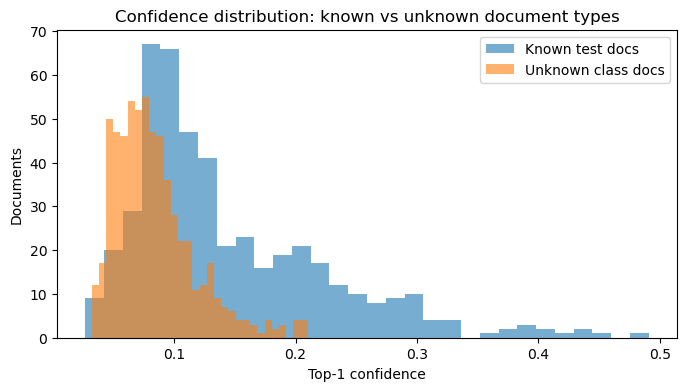

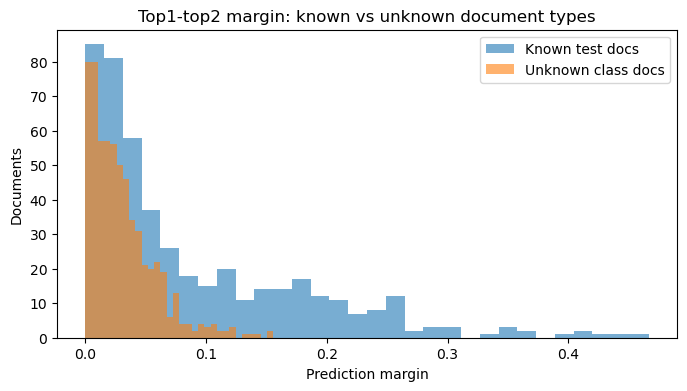

In [34]:
plt.figure(figsize=(8, 4))
plt.hist(known_conf, bins=30, alpha=0.6, label="Known test docs")
plt.hist(unknown_conf, bins=30, alpha=0.6, label="Unknown class docs")
plt.title("Confidence distribution: known vs unknown document types")
plt.xlabel("Top-1 confidence")
plt.ylabel("Documents")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(known_margin, bins=30, alpha=0.6, label="Known test docs")
plt.hist(unknown_margin, bins=30, alpha=0.6, label="Unknown class docs")
plt.title("Top1-top2 margin: known vs unknown document types")
plt.xlabel("Prediction margin")
plt.ylabel("Documents")
plt.legend()
plt.show()

### 1. Confidence Histogram 해석

* **Known (파란색):** 비교적 오른쪽(높은 Confidence 쪽)으로 넓게 퍼져 있습니다. 모델이 학습한 데이터는 확실하게 "이거다!"라고 자신 있게 예측하고 있다는 뜻입니다.
* **Unknown (주황색):** 왼쪽(낮은 Confidence 쪽)에 뾰족하게 쏠려 있습니다. 모델이 낯선 문서를 만났을 때, "뭐지? 확실하지 않은데..."라며 **자신감이 떨어진 상태**임을 보여줍니다.
* **핵심:** 두 분포가 완전히 겹치지 않고 왼쪽/오른쪽으로 나뉘어 있다는 것은, **Confidence만으로도 어느 정도는 Known과 Unknown을 구분할 수 있다**는 희망적인 신호입니다.

### 2. Margin Histogram 해석

* 이 그래프가 **실무적으로는 훨씬 더 강력한 무기**입니다.
* **Known:** Margin이 0.1~0.2 이상으로 꽤 높게 나옵니다. 1등 후보가 2등 후보를 확실하게 따돌리고 있다는 뜻입니다.
* **Unknown:** Margin이 거의 0에 가깝게 붙어 있습니다. 모델이 1등과 2등 사이에서 "A일까? B일까?" 하며 갈팡질팡하고 있다는 증거입니다.
* **핵심:** Confidence보다 **Margin의 분포 차이가 더 뚜렷하다면**, Margin이 Unknown을 걸러내는(Detecting) 데 더 정확한 지표라는 뜻입니다.

### 3. 면접관에게 이 결과를 설명하는 방법

이 플롯들을 보여주며 이렇게 답변해 보세요:

> "이 히스토그램들은 **'모델의 불확실성(Uncertainty)'**을 시각화한 것입니다.
> 보시다시피 Unknown 클래스는 Known 클래스에 비해 Confidence와 Margin 모두 낮게 형성됩니다. 특히 **Margin이 낮다는 것은 모델이 상위 후보군 사이에서 혼란을 겪고 있다**는 결정적인 단서입니다.
> 실무에서는 이 Margin 값을 기반으로 **'Unknown 탐지 임계값'**을 설정할 것입니다. 만약 특정 문서의 Margin이 임계값보다 낮다면, 이는 우리 시스템이 학습하지 못한 새로운 유형의 문서일 가능성이 높으므로, 즉시 자동 분류를 중단하고 **사람의 눈으로 확인하는(Human-in-the-loop) 절차**로 넘길 것입니다."

### 요약

* **Confidence:** 모델의 "자신감" (높을수록 좋음)
* **Margin:** 모델의 "판단 명확성" (높을수록 1등과 2등의 차이가 큼)
* **이 플롯의 가치:** "우리 모델은 모르는 문서가 들어오면 Conf와 Margin이 낮아지기 때문에, **시스템적으로 이상 징후를 감지하고 방어할 수 있다**"는 것을 증명함.

In [35]:
# Choose a simple threshold to flag potential unknowns
UNKNOWN_CONF_THRESHOLD = 0.55
UNKNOWN_MARGIN_THRESHOLD = 0.15

test_unknown_pred = balanced_model.predict(test_unknown_df["text_redacted"])
unknown_review_flag = (unknown_conf < UNKNOWN_CONF_THRESHOLD) | (unknown_margin < UNKNOWN_MARGIN_THRESHOLD)

print("Unknown documents flagged for review:", round(unknown_review_flag.mean(), 3))
print("If we did not flag them, model would force them into known classes such as:")
pd.Series(test_unknown_pred).value_counts().head(10).to_frame("forced_known_prediction")

Unknown documents flagged for review: 1.0
If we did not flag them, model would force them into known classes such as:


,forced_known_prediction
Auto - Supplemental Police Report,413
Auto - Citation Report,60
Auto - Rental Extension Request,29
Auto - Towing Receipt,17
Auto - Witness Statement,17
Payment - Repair Receipt,12
Auto - Loss of Use Statement,11
Correspondence - Address Change Form,10
Auto - Photo Notice,9
Auto - Claimant Statement,8


### 1. 안전장치 (Threshold) 설정

* `UNKNOWN_CONF_THRESHOLD = 0.55`: 모델의 확신도(Confidence)가 55% 미만이면 "이 문서는 모델이 잘 모르는 것"이라고 판단합니다.
* `UNKNOWN_MARGIN_THRESHOLD = 0.15`: 1등 후보와 2등 후보의 확률 차이(Margin)가 15% 미만이면 "모델이 1, 2등 사이에서 헷갈리고 있구나"라고 판단합니다.

### 2. 리뷰 플래그(Review Flag) 생성

* `unknown_review_flag`는 "이 문서가 확신도가 낮거나(55% 미만) or 1, 2등을 헷갈려 한다면(Margin 15% 미만) 사람에게 검토(Human Review)를 보내라"는 조건식입니다.
* 이 조건에 걸리는 문서들은 자동으로 처리하지 않고 사람에게 보내지게 됩니다.

### 3. 결과 출력의 의미

* `print("Unknown documents flagged for review:", ...)`: 전체 모르는 문서 중에서 **몇 %가 안전하게 '사람의 검토'로 넘어갔는지** 보여줍니다.
* `pd.Series(test_unknown_pred).value_counts()...`: 이게 가장 핵심입니다. "만약 이 안전장치가 없었다면, 모델이 이 낯선 문서들을 어떤 클래스라고 착각(오분류)했을지"를 보여줍니다.
* 결과 표를 보면 'Auto - Supplemental Police Report' 같은 클래스가 많이 보이는데, 이는 모델이 낯선 문서를 보고 엉뚱하게 이런 카테고리로 잘못 분류했다는 뜻입니다.



### 요약하자면

이 코드는 "모델이 모르는 것을 모른다고 말하게 만드는(Know when it doesn't know) 기술적 방법"입니다.

면접에서 이 코드를 설명할 때 이렇게 말하면 아주 좋습니다.

> "모델은 본 적 없는 데이터가 들어와도 무조건 하나를 찍어버리는 경향이 있습니다. 이를 방지하기 위해 **Confidence와 Margin 기반의 필터를 설정**했고, 이를 통해 잘못된 예측(Forced prediction)이 자동화 프로세스로 흘러 들어가는 것을 방지합니다. 이렇게 걸러진 문서들은 **Human-in-the-loop** 프로세스를 통해 사람이 최종 검토하게 하여 시스템의 신뢰성을 확보합니다."

In [36]:
unknown_examples = test_unknown_df.copy().reset_index(drop=True)
unknown_examples["forced_prediction"] = test_unknown_pred
unknown_examples["confidence"] = unknown_conf
unknown_examples["margin"] = unknown_margin
unknown_examples["flagged_for_review"] = unknown_review_flag

unknown_examples[["document_type", "forced_prediction", "confidence", "margin", "flagged_for_review", "text_redacted"]].head(10)

,document_type,forced_prediction,confidence,margin,flagged_for_review,text_redacted
0,Correspondence - Contact Information Form,Correspondence - Address Change Form,0.180200,0.133257,True,contact information. address change. form. date of loss 2025-08-02. information. form. contact. customer message. notice. email. policyholder [NAME]. addres...
1,Correspondence - Contact Information Form,Correspondence - Consent Form,0.100597,0.023167,True,consent. contact. form. coverage question. form. address change. status update. information. received through email. customer message. received through email.
2,Correspondence - Contact Information Form,Correspondence - Consent Form,0.113085,0.045854,True,please review and route to the appropriate w0rkflow. general corrspondence. contact. information. claim number [CLAIM_ID]. form. form. consent. contact info...
3,Correspondence - Contact Information Form,Correspondence - Consent Form,0.083904,0.028764,True,contact. signature. status update. please review and route to the appropriate workflow. email. form. consent. form submission. information. please review an...
4,Correspondence - Contact Information Form,Correspondence - Address Change Form,0.112131,0.044397,True,phone [PHONE]. document uploaded to claim file. information. address change. please review and route to the appropriate workflow. email [EMAIL]. c1aim inqui...
5,Correspondence - Contact Information Form,Correspondence - Consent Form,0.045893,0.018287,True,phone [PHONE]. supporting documentation. date of loss 2025-05-02. information. signature. general correspondence. letter. form. email [EMAIL]. n0tice. docum...
6,Correspondence - Contact Information Form,Correspondence - Address Change Form,0.128323,0.034662,True,information. address change. consent. review document. related to claim handling and coverage review. contact information. form. notice. claim file. contact...
7,Correspondence - Contact Information Form,Correspondence - Address Change Form,0.175427,0.035250,True,form submission. claim number [CLAIM_ID]. contact. form. inf0rmation. address change. policyholder [NAME]. form. notice. consent. status update.
8,Correspondence - Contact Information Form,Correspondence - Address Change Form,0.060639,0.010277,True,email [EMAIL]. coverage question. address change. policyholder [NAME]. contact. insurance claim documentation. phone [PHONE]. claim file. customer message. ...
9,Correspondence - Contact Information Form,Correspondence - Address Change Form,0.131045,0.014284,True,contact information. general correspondence. notice. signature. contact. related to claim handling and coverage review. address change. date of loss 2025-10...


# Error analysis: similar document types

Large multi-class 문제에서는 단순 FP/FN보다 **어떤 class끼리 헷갈리는지**가 중요합니다.

예:
- Medical Bill vs Medical Receipt
- Attorney Correspondence vs Settlement Demand
- Repair Estimate vs Supplemental Estimate
- Customer Letter vs Customer Email

## Interview wording

> I would examine the confusion matrix and error examples to identify which document types are being confused.  
> If the confusion is between truly similar classes, the issue may be taxonomy definition or labeling consistency, not just model performance.

In [37]:
# ============================================================
# 13. Error analysis
# ============================================================

test_pred = balanced_model.predict(test_known_df["text_redacted"])
test_proba = balanced_model.predict_proba(test_known_df["text_redacted"])
test_conf = test_proba.max(axis=1)

errors_df = test_known_df.copy().reset_index(drop=True)
errors_df["prediction"] = test_pred
errors_df["confidence"] = test_conf
errors_df["correct"] = errors_df["prediction"] == errors_df["document_type"]

print("Known test accuracy:", round(errors_df["correct"].mean(), 3))
print("Number of errors:", (~errors_df["correct"]).sum())

errors_df.loc[~errors_df["correct"], ["document_type", "prediction", "confidence", "text_redacted"]].head(12)

Known test accuracy: 0.852
Number of errors: 69


,document_type,prediction,confidence,text_redacted
1,Property - Roof Estimate,Property - Fire Damage Estimate,0.086606,scope of work. roof. labor cost. received through web portal. cause of los5. dwelling. rcpair estimate. fire damage. document uploaded to claim file. estimate.
5,Property - Photo Sheet,Property - Cause of Loss Report,0.062442,photos attached. inspection report. dwelling. cause determination. photo. sheet. cause of loss. contractor. please review and route to the appropriate workf...
30,Property - Roof Estimate,Property - Fire Damage Estimate,0.050808,water damage. insurance claim documentation. repair estimate. phone [PHONE]. fire damage. workflow oting. estimate. roof. attached pages. contractor. l@bor ...
33,Correspondence - Claim Acknowledgment Letter,Correspondence - Coverage Letter,0.133909,general correspondence. letter. related to claim handling and coverage review. status update. policyholder. policyholder [NAME]. letter. claim. claim status...
34,Auto - Claimant Statement,Auto - Witness Statement,0.103397,accident description. liability review. policyholder [NAME]. witness. claimant. statement. recorded interview. received through agent upload. vehicle collis...
49,Payment - Electronic Payment Form,Payment - Payment Stop Request,0.210971,ACH. ACH. payment issued. related to claim handling and coverage review. payment. stop payment. vendor. form. electronic. payment request. insurance claim d...
60,Auto - Witness Statement,Auto - Recorded Interview Summary,0.122962,traffic. related to claim handling and coverage review. insurance claim documentation. accident description. driver involved. witness. recorded interview. i...
71,Auto - Claimant Statement,Auto - Witness Statement,0.078974,email [EMAIL]. witness. phone [PHONE]. related to claim handling and coverage review. vehicle damage. claimant. auto accident. statement. policyholder [NAME...
76,Correspondence - Provider Email,Correspondence - Agent Email,0.064749,policyholder [NAME]. messae. claim number [CLAIM_ID]. provider. status update. from. subject. coverage question. claim inquiry. email.
78,Property - Contractor Bid,Property - Repair Completion Certificate,0.088002,bid. workflow routing. contractor. rcpair work. completion certificate. related to claim handling and coverage review. water damage. contractor invoice. sup...


In [38]:
# Most common confusions
confusions = (
    errors_df.loc[~errors_df["correct"]]
    .groupby(["document_type", "prediction"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusions.head(15)

,document_type,prediction,count
0,Auto - Claimant Statement,Auto - Witness Statement,3
5,Correspondence - Claim Acknowledgment Letter,Correspondence - Coverage Letter,2
9,Correspondence - Customer Email,Correspondence - Provider Email,2
4,Correspondence - Agent Email,Correspondence - Customer Email,2
7,Correspondence - Coverage Letter,Correspondence - Status Letter,2
50,Property - Inventory Form,Property - Sworn Proof of Loss,2
43,Property - Contents Estimate,Property - Fire Damage Estimate,2
45,Property - Contractor Invoice,Property - Repair Completion Certificate,2
57,Property - Roof Estimate,Property - Fire Damage Estimate,2
29,Payment - Electronic Payment Form,Payment - Payment Stop Request,2


# Lightweight embedding-like approach: TF-IDF + SVD + cosine similarity

이번 이메일은 transformer를 반드시 쓰라는 뜻이 아닙니다.  
하지만 **large label space / new class / rare class**를 설명할 때 embedding similarity 사고방식은 유용합니다.

여기서는 외부 다운로드 없이 `TF-IDF + SVD`로 dense vector를 만들고, 각 class의 prototype vector와 cosine similarity를 비교합니다.

이것은 실제 Sentence Transformer와 완전히 같지는 않지만, 다음 개념을 이해하는 데 도움이 됩니다.

- document를 dense vector로 표현
- class별 평균 vector를 prototype으로 사용
- incoming document를 가장 가까운 class에 매칭
- 신규 class가 생기면 few examples로 prototype 추가 가능

## Interview wording

> For stable known classes, I would use a supervised classifier.  
> If new document types are frequently added, I would also consider an embedding-based similarity approach, where new class examples or class descriptions can be added more flexibly.

In [39]:
# ============================================================
# 14. TF-IDF + SVD embedding-like approach
# ============================================================

svd_vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1,2), min_df=2, max_df=0.95)
X_train_tfidf = svd_vectorizer.fit_transform(train_df["text_redacted"])
X_val_tfidf = svd_vectorizer.transform(val_df["text_redacted"])

svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd = svd.transform(X_val_tfidf)

print("TF-IDF shape:", X_train_tfidf.shape)
print("SVD dense embedding shape:", X_train_svd.shape)
print("Explained variance ratio:", round(svd.explained_variance_ratio_.sum(), 3))

TF-IDF shape: (1730, 5475)
SVD dense embedding shape: (1730, 100)
Explained variance ratio: 0.464


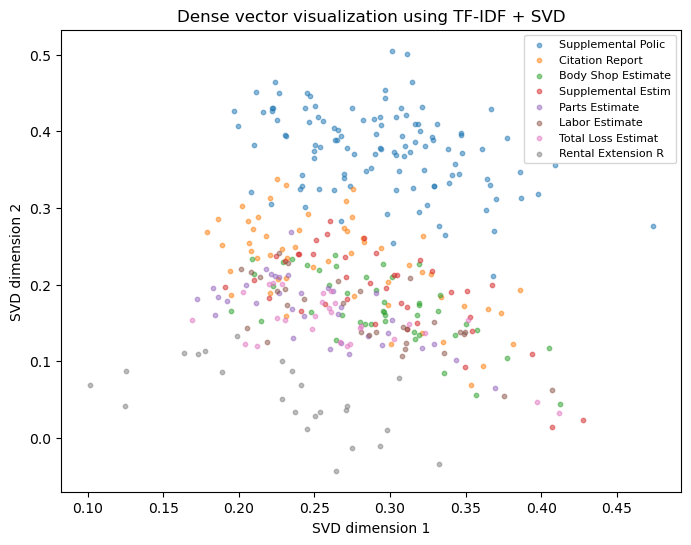

In [40]:
# Visualize first two SVD dimensions for a small sample of classes
sample_classes = train_df["document_type"].value_counts().head(8).index.tolist()
sample_mask = train_df["document_type"].isin(sample_classes).values
sample_idx = np.where(sample_mask)[0]
sample_idx = np.random.choice(sample_idx, size=min(800, len(sample_idx)), replace=False)

plt.figure(figsize=(8, 6))
for cls in sample_classes:
    idx = sample_idx[train_df.iloc[sample_idx]["document_type"].values == cls]
    plt.scatter(X_train_svd[idx, 0], X_train_svd[idx, 1], s=10, alpha=0.5, label=cls.split(" - ")[-1][:18])
plt.title("Dense vector visualization using TF-IDF + SVD")
plt.xlabel("SVD dimension 1")
plt.ylabel("SVD dimension 2")
plt.legend(fontsize=8)
plt.show()

In [41]:
# Prototype classifier: mean vector per class + cosine similarity

class_prototypes = {}
for cls in train_df["document_type"].unique():
    idx = train_df["document_type"].values == cls
    class_prototypes[cls] = X_train_svd[idx].mean(axis=0)

prototype_classes = np.array(list(class_prototypes.keys()))
prototype_matrix = np.vstack([class_prototypes[c] for c in prototype_classes])

sim = cosine_similarity(X_val_svd, prototype_matrix)
proto_top1 = prototype_classes[np.argmax(sim, axis=1)]

proto_accuracy = accuracy_score(val_df["document_type"], proto_top1)
proto_macro_f1 = f1_score(val_df["document_type"], proto_top1, average="macro")

# top-3 for prototype
top3_idx = np.argsort(sim, axis=1)[:, ::-1][:, :3]
proto_top3 = [[prototype_classes[j] for j in row] for row in top3_idx]
proto_top3_acc = np.mean([true in preds for true, preds in zip(val_df["document_type"].values, proto_top3)])

pd.DataFrame([{
    "model": "TF-IDF + SVD prototype cosine",
    "accuracy": proto_accuracy,
    "macro_f1": proto_macro_f1,
    "top3_accuracy": proto_top3_acc
}])

,model,accuracy,macro_f1,top3_accuracy
0,TF-IDF + SVD prototype cosine,0.648069,0.561308,0.927039


## How to interpret embedding/prototype results

이 방식이 반드시 supervised classifier보다 좋다는 뜻은 아닙니다.

중요한 메시지는 이것입니다.

| Situation | Better fit |
|---|---|
| Stable known classes | Supervised classifier |
| Many new classes | Embedding/prototype approach may help |
| Rare class few-shot support | Embedding/prototype approach may help |
| Strict top-1 automation | Supervised classifier often stronger |
| Human review with top-k suggestions | Embedding similarity can be useful |

---

## Interview wording

> I would not assume embedding similarity is always better.  
> I would compare it against the supervised baseline.  
> Its main advantage is flexibility for new or rare document types, especially when combined with human review.

# Few-shot new class support demonstration

이제 unknown class를 일부러 training에서 제외했지만, production에서 human reviewer가 새 class의 examples를 몇 개 labeling했다고 가정합니다.

질문:

> 새 class가 생길 때마다 전체 모델을 재학습해야 하나?

대답:

- Softmax classifier는 보통 재학습 필요
- Embedding/prototype 방식은 few examples를 prototype으로 추가할 수 있음
- 다만 production 품질 보장을 위해 결국 재학습/검증 프로세스가 필요

여기서는 unknown class당 5개 examples만 prototype으로 추가해봅니다.

In [42]:
# ============================================================
# 15. Few-shot unknown class prototype demonstration
# ============================================================

# Build embeddings for unknown docs
X_unknown_tfidf = svd_vectorizer.transform(test_unknown_df["text_redacted"])
X_unknown_svd = svd.transform(X_unknown_tfidf)

few_shot_rows = []
remaining_rows = []

for cls, group in test_unknown_df.reset_index(drop=True).groupby("document_type"):
    if len(group) < 8:
        continue
    few = group.sample(n=min(5, len(group)//2), random_state=RANDOM_STATE)
    rest = group.drop(few.index)
    few_shot_rows.append(few)
    remaining_rows.append(rest)

few_shot_df = pd.concat(few_shot_rows).reset_index(drop=True)
remaining_unknown_df = pd.concat(remaining_rows).reset_index(drop=True)

X_few_tfidf = svd_vectorizer.transform(few_shot_df["text_redacted"])
X_few_svd = svd.transform(X_few_tfidf)

# Add new prototypes for unknown classes
extended_prototypes = dict(class_prototypes)

for cls in few_shot_df["document_type"].unique():
    idx = few_shot_df["document_type"].values == cls
    extended_prototypes[cls] = X_few_svd[idx].mean(axis=0)

extended_classes = np.array(list(extended_prototypes.keys()))
extended_matrix = np.vstack([extended_prototypes[c] for c in extended_classes])

X_remaining_tfidf = svd_vectorizer.transform(remaining_unknown_df["text_redacted"])
X_remaining_svd = svd.transform(X_remaining_tfidf)

sim_remaining = cosine_similarity(X_remaining_svd, extended_matrix)
fewshot_pred = extended_classes[np.argmax(sim_remaining, axis=1)]

fewshot_acc = accuracy_score(remaining_unknown_df["document_type"], fewshot_pred)
fewshot_top3_idx = np.argsort(sim_remaining, axis=1)[:, ::-1][:, :3]
fewshot_top3 = [[extended_classes[j] for j in row] for row in fewshot_top3_idx]
fewshot_top3_acc = np.mean([true in preds for true, preds in zip(remaining_unknown_df["document_type"].values, fewshot_top3)])

print("Few-shot unknown class top-1 accuracy:", round(fewshot_acc, 3))
print("Few-shot unknown class top-3 accuracy:", round(fewshot_top3_acc, 3))

Few-shot unknown class top-1 accuracy: 0.333
Few-shot unknown class top-3 accuracy: 0.897


# Hierarchical classification

사진에서 공유한 아이디어처럼, 100+ class 문제는 계층적으로 나눌 수 있습니다.

예:

1. Line of business  
   - Auto / Property / Medical / Legal / Payment / Correspondence

2. Document group  
   - Medical Bill / Medical Record / Attorney / Demand / Invoice

3. Detailed document type  
   - Emergency Room Bill / Attorney Representation Letter / Rental Invoice

---

## 장점

- 각 단계의 class 수가 줄어듦
- taxonomy가 business workflow와 잘 맞을 수 있음
- human reviewer에게 설명하기 쉬움

## 단점

- 1단계에서 틀리면 2, 3단계가 전부 틀릴 수 있음
- error cascade 발생 가능
- taxonomy 관리가 복잡해질 수 있음

## Interview wording

> Hierarchical classification can reduce the complexity of a large label space, but it introduces error cascade risk.  
> If the top-level category is wrong, downstream classifiers may never consider the correct detailed class.  
> I would evaluate both flat and hierarchical approaches and consider top-k routing at the higher levels.

In [43]:
# ============================================================
# 16. Hierarchical classification demonstration
# ============================================================

# Step 1: top-level LOB classifier
lob_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=2)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE))
])

lob_model.fit(train_df["text_redacted"], train_df["line_of_business"])
lob_pred = lob_model.predict(test_known_df["text_redacted"])

lob_acc = accuracy_score(test_known_df["line_of_business"], lob_pred)
print("Top-level line of business accuracy:", round(lob_acc, 3))

Top-level line of business accuracy: 1.0


In [44]:
# Train branch-specific detailed classifiers
branch_models = {}

for lob in train_df["line_of_business"].unique():
    branch_train = train_df[train_df["line_of_business"] == lob]
    # only train if multiple document types exist
    if branch_train["document_type"].nunique() < 2:
        continue
    model = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=7000, ngram_range=(1,2), min_df=2)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE))
    ])
    model.fit(branch_train["text_redacted"], branch_train["document_type"])
    branch_models[lob] = model

# Hierarchical prediction
hier_preds = []
for text, predicted_lob in zip(test_known_df["text_redacted"], lob_pred):
    if predicted_lob in branch_models:
        hier_preds.append(branch_models[predicted_lob].predict([text])[0])
    else:
        hier_preds.append("UNKNOWN_BRANCH")

hier_acc = accuracy_score(test_known_df["document_type"], hier_preds)
flat_acc = accuracy_score(test_known_df["document_type"], test_pred)

pd.DataFrame([
    {"approach": "Flat 100+ class classifier", "detailed_type_accuracy": flat_acc},
    {"approach": "Hierarchical classifier", "detailed_type_accuracy": hier_acc},
])

,approach,detailed_type_accuracy
0,Flat 100+ class classifier,0.851931
1,Hierarchical classifier,0.849785


In [45]:
hier_errors = test_known_df.copy().reset_index(drop=True)
hier_errors["predicted_lob"] = lob_pred
hier_errors["hier_prediction"] = hier_preds
hier_errors["lob_correct"] = hier_errors["predicted_lob"] == hier_errors["line_of_business"]
hier_errors["detail_correct"] = hier_errors["hier_prediction"] == hier_errors["document_type"]

cascade_errors = hier_errors[(~hier_errors["lob_correct"]) & (~hier_errors["detail_correct"])]

print("Cascade errors caused by wrong top-level branch:", len(cascade_errors))
cascade_errors[["line_of_business", "predicted_lob", "document_type", "hier_prediction", "text_redacted"]].head(8)

Cascade errors caused by wrong top-level branch: 0


,line_of_business,predicted_lob,document_type,hier_prediction,text_redacted


# Stage 4 — Production monitoring and maintenance

Production에서는 모델 성능만 보는 것이 아닙니다.

Regulated insurance environment에서는 다음을 봐야 합니다.

## Monitoring dimensions

1. **Input data drift**
   - OCR quality changes
   - New document templates
   - New vendor forms
   - Text length distribution changes

2. **Prediction drift**
   - Class distribution changes
   - Confidence distribution changes
   - Unknown/manual review rate increases

3. **Performance drift**
   - Per-class recall
   - Human override rate
   - Top-k acceptance rate

4. **Governance**
   - Model versioning
   - Audit trail
   - Human override logs
   - Taxonomy changes
   - Retraining approval process

---

## Interview wording

> In production, I would monitor not only aggregate accuracy but also per-class performance, confidence distribution, unknown document rate, human override rate, OCR quality, and document template drift.  
> In a regulated environment, I would also maintain model versioning, audit trails, and a feedback loop from human reviewers.

In [46]:
# ============================================================
# 17. Drift simulation
# ============================================================

def generate_future_batch(n=1200, drift_strength=0.35):
    # Future batch with more legal/medical docs and lower OCR quality
    future_rows = []
    future_tax = taxonomy.copy()

    # Increase probability for Legal and Medical
    weights = []
    for _, row in future_tax.iterrows():
        base = 1.0
        if row["line_of_business"] in ["Legal", "Medical"]:
            base += 2.0 * drift_strength
        if "Blank Page" in row["document_type"] or "Unclear" in row["document_type"]:
            base += 1.5 * drift_strength
        weights.append(base)
    weights = np.array(weights)
    weights = weights / weights.sum()

    for i in range(n):
        trow = future_tax.iloc[np.random.choice(len(future_tax), p=weights)]
        claim_id = f"FUT{200000+i}"
        # lower OCR quality in future
        ocr_quality = np.clip(np.random.beta(5, 3), 0, 1)
        noise_severity = max(0, 1 - ocr_quality)
        text = generate_doc_text(trow, claim_id=claim_id, add_pii=True, ocr_noise=noise_severity)
        future_rows.append({
            "document_id": f"FDOC{200000+i}",
            "text": redact_pii(text),
            "document_type": trow["document_type"],
            "line_of_business": trow["line_of_business"],
            "document_group": trow["document_group"],
            "ocr_quality": float(ocr_quality),
        })

    return pd.DataFrame(future_rows)

future_df = generate_future_batch(n=1500, drift_strength=0.7)
future_pred = balanced_model.predict(future_df["text"])
future_proba = balanced_model.predict_proba(future_df["text"])
future_conf = future_proba.max(axis=1)
future_correct = future_pred == future_df["document_type"].values

print("Future batch accuracy:", round(np.mean(future_correct), 3))
print("Future average confidence:", round(np.mean(future_conf), 3))
print("Future average OCR quality:", round(future_df["ocr_quality"].mean(), 3))

Future batch accuracy: 0.791
Future average confidence: 0.13
Future average OCR quality: 0.625


In [47]:
# Compare LOB distribution train vs future
train_lob_dist = train_df["line_of_business"].value_counts(normalize=True).rename("train")
future_lob_dist = future_df["line_of_business"].value_counts(normalize=True).rename("future")
lob_drift = pd.concat([train_lob_dist, future_lob_dist], axis=1).fillna(0)
lob_drift

,train,future
line_of_business,,
Auto,0.289595,0.106667
Property,0.169942,0.096000
Medical,0.157225,0.277333
Legal,0.138728,0.270667
Payment,0.123699,0.113333
Correspondence,0.120809,0.136000


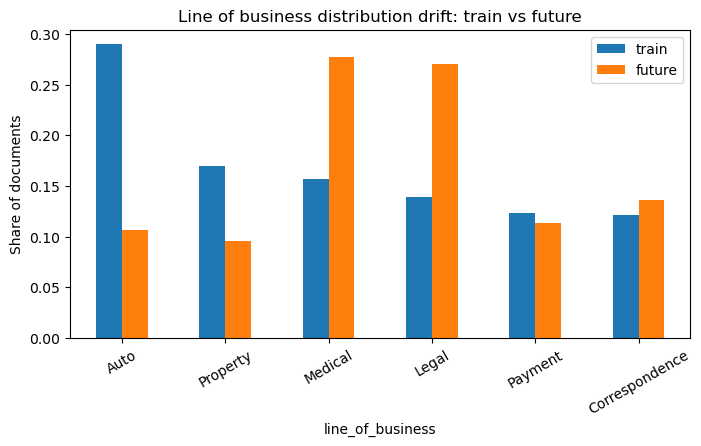

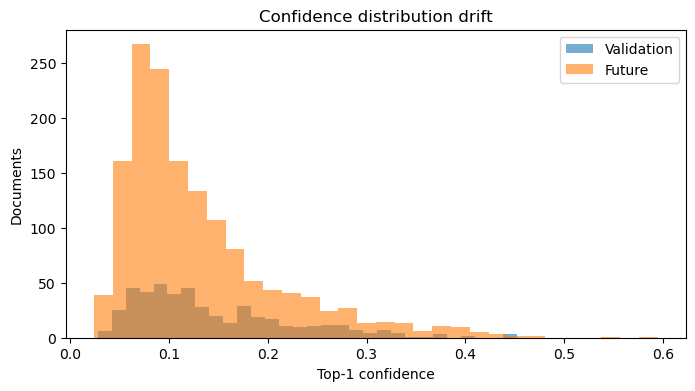

In [48]:
lob_drift.plot(kind="bar", figsize=(8,4))
plt.title("Line of business distribution drift: train vs future")
plt.ylabel("Share of documents")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8,4))
plt.hist(val_confidence, bins=30, alpha=0.6, label="Validation")
plt.hist(future_conf, bins=30, alpha=0.6, label="Future")
plt.title("Confidence distribution drift")
plt.xlabel("Top-1 confidence")
plt.ylabel("Documents")
plt.legend()
plt.show()

# Production dashboard idea

실제 운영에서는 이런 지표를 주기적으로 봅니다.

| Monitoring metric | Why it matters |
|---|---|
| Volume by document type | Detect class distribution drift |
| OCR quality | Low OCR quality can hurt classification |
| Average confidence | Confidence collapse may indicate drift |
| Manual review rate | Operational workload |
| Human override rate | Model quality / label issue |
| Unknown document rate | New templates/classes |
| Per-class recall | Rare/high-risk class protection |
| Top-k acceptance rate | HITL productivity |
| Retraining data volume | Maintenance planning |
| Model version | Auditability |

---

## Interview wording

> I would build monitoring around model behavior and operational outcomes.  
> If manual review rate or human override rate increases, that may indicate drift, new document types, or label taxonomy changes.  
> I would capture human corrections as feedback data for retraining.

# Optional: Transformer section

이번 이메일은 "NLP techniques"를 말하지만, 반드시 transformer fine-tuning을 직접 구현하라는 뜻은 아닙니다.  
면접에서는 오히려 다음 균형이 중요합니다.

- baseline부터 시작
- large label space의 실무 문제를 설명
- transformer는 후보 모델 중 하나로 다룸
- cost, latency, monitoring, retraining, governance를 같이 고려

## Interview wording

> I would consider transformer-based models if the baseline struggles with semantic similarity or OCR/noisy text.  
> But I would compare them against a TF-IDF baseline and consider latency, cost, explainability, calibration, and operational reliability before production deployment.

아래 코드는 기본 실행하지 않습니다. 로컬에서 `RUN_SENTENCE_TRANSFORMER = True`로 바꾸면 시도할 수 있습니다.

In [ ]:
# ============================================================
# 18. Optional sentence-transformer embeddings
# ============================================================

RUN_SENTENCE_TRANSFORMER = False

if RUN_SENTENCE_TRANSFORMER:
    # Install first if needed:
    # pip install sentence-transformers
    from sentence_transformers import SentenceTransformer

    st_model = SentenceTransformer("all-MiniLM-L6-v2")

    sample_train = train_df.sample(1000, random_state=RANDOM_STATE)
    sample_val = val_df.sample(300, random_state=RANDOM_STATE)

    train_emb = st_model.encode(sample_train["text_redacted"].tolist(), show_progress_bar=True)
    val_emb = st_model.encode(sample_val["text_redacted"].tolist(), show_progress_bar=True)

    emb_clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    emb_clf.fit(train_emb, sample_train["document_type"])
    emb_pred = emb_clf.predict(val_emb)

    print("Sentence-transformer sample accuracy:", accuracy_score(sample_val["document_type"], emb_pred))
    print("Sentence-transformer sample macro F1:", f1_score(sample_val["document_type"], emb_pred, average="macro"))
else:
    print("Sentence-transformer section skipped. Set RUN_SENTENCE_TRANSFORMER = True to run locally.")

# Final interview framework

아래는 이번 라운드에서 바로 사용할 수 있는 structured answer입니다.

## 60-second opening answer

> I would treat this as a large-scale single-label multi-class document classification problem.  
> Since there are 100+ document types, I would first clarify the document taxonomy, label definitions, data sources, OCR quality, and business workflow triggered by each class.  
> Then I would explore class distribution, rare classes, text length, OCR noise, and label quality.  
> I would start with a strong baseline such as TF-IDF plus a linear classifier, then compare it with transformer or embedding-based approaches if needed.  
> For evaluation, I would look beyond accuracy and use macro F1, weighted F1, per-class recall, top-k accuracy, confidence calibration, and human review outcomes.  
> In production, I would design confidence thresholds, human-in-the-loop review, unknown document handling, monitoring for drift, and a feedback loop from human overrides.

---

## If interviewer asks: Why does 100+ classes matter?

> With 100+ classes, the problem becomes a large label space problem.  
> Overall accuracy can hide poor performance on rare classes.  
> Similar document types can be confused, and new document types may appear in production.  
> So I would evaluate per-class performance, top-k accuracy, rare class recall, and unknown handling.

---

## If interviewer asks: What model would you start with?

> I would start with TF-IDF plus a linear classifier as a baseline because it is fast, interpretable, and often strong for document classification.  
> Then I would compare more advanced models such as transformer-based classifiers or embedding similarity methods depending on the need for semantic understanding, new class support, latency, and operational reliability.

---

## If interviewer asks: How do you handle rare classes?

> I would first quantify class imbalance and look at per-class support and recall.  
> Then I would consider class weighting, collecting more examples, targeted data augmentation, class-specific thresholds, or human review for rare but high-risk document types.  
> I would not rely only on overall accuracy.

---

## If interviewer asks: How do you handle unknown document types?

> A closed-set classifier will force every document into one of the known classes.  
> To handle unknowns, I would use confidence and margin thresholds, possibly embedding similarity thresholds, and route uncertain documents to a human review queue.  
> Human-labeled unknowns can then feed into taxonomy updates and retraining.

---

## If interviewer asks: How would human-in-the-loop work?

> High-confidence documents can be auto-classified.  
> Medium-confidence documents can show top-3 predictions to a reviewer.  
> Low-confidence or high-risk documents should go to manual review.  
> Reviewer corrections should be logged and used for monitoring, retraining, and taxonomy improvement.

---

## If interviewer asks: How do you monitor this in production?

> I would monitor class distribution, OCR quality, confidence distribution, unknown rate, manual review rate, human override rate, per-class performance, and top-k acceptance rate.  
> In a regulated insurance environment, I would also maintain audit logs, model versioning, and clear retraining governance.

# Quick self-test flashcards

## Q1. Is this binary classification?
**A.** No. It is a large-scale single-label multi-class document classification problem.

## Q2. Why is overall accuracy not enough?
**A.** Because common classes can dominate accuracy while rare classes perform poorly.

## Q3. What metrics would you use?
**A.** Accuracy, macro F1, weighted F1, per-class recall, top-k accuracy, calibration, and human review metrics.

## Q4. What is top-k accuracy?
**A.** Whether the true document type appears within the top k predicted classes.

## Q5. Why is HITL important?
**A.** Because low-confidence or high-risk documents should not be blindly auto-classified in a regulated environment.

## Q6. What is unknown class handling?
**A.** Detecting or routing documents that do not fit any known training class.

## Q7. What is error cascade in hierarchical classification?
**A.** If the top-level classifier chooses the wrong branch, downstream classifiers may never consider the correct detailed class.

## Q8. What production signals would you monitor?
**A.** OCR quality, class distribution, confidence, manual review rate, override rate, unknown rate, and per-class performance.